# Imports

In [3]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # pick whichever GPU has more free memory
# os.environ["CUDA_VISIBLE_DEVICES"] = "" 
# os.environ["JAX_PLATFORMS"] = "cpu"
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
from cosmographi.utils.perturbations import generate_perturbations_vector
import jax.numpy as jnp 
from cosmographi.source import Source
from cosmographi.source.agn import AGNSourceLipunova2018, AGNSourceLipunova2018_invariable
from cosmographi.instrument import Instrument
from cosmographi.instrument.rubin import RubinObservatory
import numpy as np
import jax
import matplotlib.pyplot as plt
from cosmographi.utils.constants import M_sun, c_nm
from cosmographi.utils.flux import convert_to_jy, observer_to_rest_time
# jax.config.update("jax_enable_x64", True)
from astropy.cosmology import Planck18
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.redshift import RedshiftDistFunc
from lightcurvelynx.base_models import FunctionNode
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableRADECSampler
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.models.agn import AGN
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.survey_info import SurveyInfo
import pandas as pd
from tinygp import GaussianProcess, kernels
from cosmographi.utils.perturbations import generate_perturbations_vector
from caskade import forward
from sklearn.neighbors import KNeighborsRegressor
from cosmographi.cosmology import Cosmology
import arviz as az
import blackjax as bx
import jax.scipy.stats as stats
from functools import partial
import cosmographi as cp

To start off, I will just substract the sample men of the perturbations. However, this is not the right way of doing it

In [4]:
# @jax.jit
# def power_spectrum_log_prior(x: jnp.ndarray, alpha: float, amplitude: float = 1.0, var_floor: float = 1e-8) -> jnp.ndarray:
#     """
#     Evaluates the log-prior probability density of a 1D real-valued array x,
#     assuming a power-law power spectrum P(k) = amplitude * k^alpha.

#     Args:
#         x: 1D array of real-valued data.
#         alpha: The power law slope of the spectrum.
#         amplitude: Scaling factor for the power spectrum.
#         var_floor: A floor applied to the total variance to prevent division
#                    by zero and ensure numerical stability in gradients.

#     Returns:
#         log_prob: The scalar log-probability density.
#     """
#     N = x.shape[0]

#     # 1. Transform to frequency domain
#     x_k = np.fft.rfft(x)
#     freqs = np.fft.rfftfreq(N)

#     # 2. Isolate non-zero frequencies
#     # The DC component (k=0) is excluded to avoid singular values.
#     # It is typically assumed the signal is mean-centered, or the mean
#     # is modeled with a separate uniform/normal prior.
#     k_nz = freqs[1:]
#     x_k_nz = x_k[1:]

#     # 3. Compute expected power spectrum variance
#     # Applying the variance floor prevents the variance from dropping to zero
#     # (e.g., at high frequencies if alpha < 0) which would cause log(0) NaNs.
#     P_k = amplitude * (k_nz ** alpha) + var_floor

#     # 4. Calculate log probability of the Fourier modes
#     # The rfft coefficients for k > 0 are independent complex Gaussians.
#     # The variance of these complex modes is proportional to P(k).
#     power_x = pt.abs(x_k_nz)**2

#     # Log PDF of a complex Gaussian: -|z|^2 / Var - log(pi * Var)
#     log_prob_modes = -(power_x / P_k) - pt.log(pt.pi * P_k)

#     # Sum over all independent modes to get the total log-prior
#     return pt.sum(log_prob_modes)



In [5]:
# def power_spectrum_log_prior(x: jnp.ndarray, freqs, alpha: float, amplitude: float = 1.0, var_floor: float = 1e-8) -> jnp.ndarray:
#     """
#     Evaluates the log-prior probability density of a 1D real-valued array x,
#     assuming a power-law power spectrum P(k) = amplitude * k^alpha.

#     Args:
#         x: 1D array of real-valued data.
#         alpha: The power law slope of the spectrum.
#         amplitude: Scaling factor for the power spectrum.
#         var_floor: A floor applied to the total variance to prevent division
#                    by zero and ensure numerical stability in gradients.

#     Returns:
#         log_prob: The scalar log-probability density.
#     """
#     N = x.shape[0]

#     # 1. Transform to frequency domain
#     x_k = ptfft.rfft(x[None, :])[0, :]

#     # 2. Isolate non-zero frequencies
#     # The DC component (k=0) is excluded to avoid singular values.
#     # It is typically assumed the signal is mean-centered, or the mean
#     # is modeled with a separate uniform/normal prior.
#     k_nz = freqs[1:]
#     x_k_nz = x_k[1:]

#     # 3. Compute expected power spectrum variance
#     # Applying the variance floor prevents the variance from dropping to zero
#     # (e.g., at high frequencies if alpha < 0) which would cause log(0) NaNs.
#     P_k = amplitude * (k_nz ** alpha) + var_floor

#     # 4. Calculate log probability of the Fourier modes
#     # The rfft coefficients for k > 0 are independent complex Gaussians.
#     # The variance of these complex modes is proportional to P(k).
#     power_x = pt.sum(pt.abs(x_k_nz)**2, axis=-1)

#     # Log PDF of a complex Gaussian: -|z|^2 / Var - log(pi * Var)
#     log_prob_modes = -(power_x / P_k) - pt.log(pt.pi * P_k)

#     # Sum over all independent modes to get the total log-prior
#     return pt.sum(log_prob_modes)



In [6]:
# def fit_agn(data):
#     data = np.asarray(data)
#     data_avg = np.mean(data)
#     data_norm = data - data_avg
#     with pm.Model() as model:
#         # priors:
#         alpha = pm.Normal("alpha", mu=1.7, sigma=1)
#         log_amplitude = pm.Normal("log_amplitude", mu=0, sigma=5)
#         sig = pm.HalfNormal("sig", 1) #TODO: should be informed from instrument noise
#         freqs = np.fft.rfftfreq(data.shape[0])
#         ps_prior = pm.CustomDist("ps_prior", freqs, alpha, pm.math.exp(log_amplitude), logp=power_spectrum_log_prior, shape=len(data_norm))
#         #likelihood
#         ps_ll = pm.Normal("ps_ll", mu=ps_prior, sigma=sig, observed=data_norm)
#         trace = pm.sample(1000, tune=1000, chains=4, target_accept=0.95, max_treedepth=15, return_inferencedata=True, progressbar=True)
#     return trace, model

In [7]:

# passband_group = PassbandGroup.from_preset(preset="LSST")
# # It will take a while to download it. It took 9 min on Helen
# obstable = OpSim.from_url(
#     "https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs4.3/baseline/baseline_v4.3.5_10yrs.db",)

# # Draw redshift from the uniform distribution
# redshift = NumpyRandomFunc("uniform", low=0.1, high=1.0)
# # Draw decimal logarithm of the black hole mass (in solar masses)
# # from the uniform distribution
# lg_bh_mass = NumpyRandomFunc("uniform", low=7.0, high=9.0)
# # Transform to mass in solar masses
# bh_mass = FunctionNode(
#     lambda lg_mass: 10**lg_mass,
#     lg_mass=lg_bh_mass,
#     node_label="bh_mass",
# )
# # Eddington ratio for the accretion rate, e.g. accretion rate to critical value ratio
# # First, we define a PDF function, for "blue" galaxies, see
# # https://github.com/burke86/imbh_forecast/blob/master/var.ipynb
# # https://ui.adsabs.harvard.edu/abs/2019ApJ...883..139S/abstract
# # https://iopscience.iop.org/article/10.3847/1538-4357/aa803b/pdf
# def edd_ratio_pdf(value):
#     xi = 10**-1.65
#     lambda_br = 10**-1.84
#     delta1 = 0.471 - 0.7
#     delta2 = 2.53
#     min_lambda = 0.01
#     max_lambda = 1.0
#     value = np.asarray(value)
#     fill_mask = (value >= min_lambda) & (value <= max_lambda)
#     prob = np.zeros_like(value)
#     prob[fill_mask] = xi / (
#         (value[fill_mask] / lambda_br) ** delta1 + (value[fill_mask] / lambda_br) ** delta2
#     )
#     return prob

# # We use a special random node to sample from this PDF
# edd_ratio = SamplePDF(edd_ratio_pdf)
# # We use a special distribution to draw positions from the survey coverage area
# radec = ObsTableRADECSampler(
#     obstable,
#     radius=3.0,  # degrees
#     node_label="ra_dec_sampler",
# )

# model = AGN(
#     # Reference time is not important for a stochastic model
#     t0=obstable.time_bounds()[0],  # reference date, the survey start
#     blackhole_mass=bh_mass,  # black hole mass in solar masses
#     edd_ratio=edd_ratio,  # accretion rate to critical accretion rate raio
#     redshift=redshift,
#     ra=radec.ra,
#     dec=radec.dec,
#     cosmology=Planck18,
#     inclination=0
# )

# # Make it reproducible
# rng = np.random.default_rng(42)

# survey_info = SurveyInfo(obstable=obstable, passband_group=passband_group)

# df = simulate_lightcurves(
#     model=model,
#     num_samples=1,
#     survey_info=survey_info,
#     param_cols=[
#         "bh_mass.lg_mass",
#         "AGN_0.edd_ratio",
#     ],
#     rng=rng,
# )

# SECS_IN_YEAR = 31536000
# data = jnp.asarray(df.loc[0, "lightcurve"][["mjd", "flux_perfect"]])
# obs_t = data[:, 0]
# flux = data[:, 1]


In [8]:
# trace, model = fit_agn(flux)
# summary_df = az.summary(trace, round_to=3)
# az.plot_trace(trace)  # plot trace diagnostics
# plt.show(block=False)
# summary_df["rel_mcse"] = summary_df["mcse_mean"] / summary_df["sd"]
# fig, axs = plt.subplots(1, 3, figsize=(18, 5))
# # Effective sample size
# axs[0].hist(summary_df["ess_bulk"], bins=30, color='saddlebrown', edgecolor='black')
# axs[0].set_title("Effective Sample Size (Bulk) Frequency")
# axs[0].set_xlabel("Effective Sample Size")
# # Rhat statistic
# axs[1].hist(summary_df["r_hat"], bins=30, color='saddlebrown', edgecolor='black')
# axs[1].set_title("R-hat Statistics Frequency")
# axs[1].set_xlabel("R-hat Statistic")
# # Relative MCSE
# axs[2].hist(summary_df["rel_mcse"], bins=30, color="saddlebrown", edgecolor="black")
# axs[2].axvline(0.05, color="red", linestyle="--", label="MCSE/SD = 5%")
# axs[2].set_title("Relative Monte Carlo Standard Error Frequency")
# axs[2].set_xlabel("Relative Monte Carlo Standard Error")
# axs[2].legend()
# for ax in axs:
#     ax.set_ylabel("Number of Model Parameter")
# plt.tight_layout()
# plt.show(block=False)

# Learning to use BackJAX

In [ ]:
key = jax.random.key(42)
true_mu = 3.0
true_sigma = 1.5
data_key, key = jax.random.split(key)
y = true_mu + true_sigma * jax.random.normal(data_key, shape=(100,))

def halfnormal_logpdf(x, scale):
    return jnp.where(x > 0,jnp.log(2.0) + stats.norm.logpdf(x, loc=0.0, scale=scale),-jnp.inf)

def log_prior(mu, sigma):
    """
    mu ~ Normal(0, 5)
    sigma ~ HalfNormal(2)
    """
    lp_mu = stats.norm.logpdf(mu, loc=0.0, scale=5.0)
    lp_sig = halfnormal_logpdf(sigma, 2)
    return lp_mu + lp_sig

def log_likelihood(y, mu, sigma):
    return jnp.sum(stats.norm.logpdf(y, mu, sigma))

def log_posterior(params):
    """params = (mu, sigma)"""
    mu, sigma = params
    return log_prior(mu, sigma) + log_likelihood(y, mu, sigma)

initial_position = jnp.array([0.0, 1.0])
warmup = bx.window_adaptation(bx.hmc, log_posterior, num_integration_steps=1000)
adaptation_results, adaptation_info = warmup.run(key, initial_position)

print(type(adaptation_results), type(adaptation_info))
print(adaptation_results.parameters)
print(adaptation_results.state)

<class 'blackjax.adaptation.base.AdaptationResults'> <class 'blackjax.adaptation.base.AdaptationInfo'>
{'step_size': Array(0.63200293, dtype=float64, weak_type=True), 'inverse_mass_matrix': Array([0.02489501, 0.00942416], dtype=float64), 'num_integration_steps': 1000}
HMCState(position=Array([2.91137598, 1.64278802], dtype=float64), logdensity=Array(-186.14653286, dtype=float64), logdensity_grad=Array([  3.3751276 , -11.78280672], dtype=float64))


In [ ]:
kernel = bx.hmc(log_posterior, **adaptation_results.parameters)
num_samples = 1000
ret = bx.util.run_inference_algorithm(key, kernel, num_samples, adaptation_results.state)
print(len(ret))
print(type(ret[0]))
print(type(ret[1]))
print(len(ret[1]))
print(type(ret[1][0]))
print(type(ret[1][1]))
print(len(ret[1][0]))
print(len(ret[1][1]))
print(ret[1][1])

2
<class 'blackjax.mcmc.hmc.HMCState'>
<class 'tuple'>
2
<class 'blackjax.mcmc.hmc.HMCState'>
<class 'blackjax.mcmc.hmc.HMCInfo'>
3
7
HMCInfo(momentum=Array([[ -2.81213278,  -3.36990663],
       [-12.27669453,  -2.97776366],
       [-19.53706009,  -6.66564106],
       ...,
       [ -0.4086898 ,   4.41478497],
       [ -0.79300235,  20.00825743],
       [ -2.09172222, -12.30413938]], dtype=float64), acceptance_rate=Array([0.97021535, 1.        , 0.94214967, 1.        , 0.84708454,
       1.        , 0.95741115, 0.99939959, 1.        , 0.87276134,
       0.9080794 , 1.        , 1.        , 0.98961673, 1.        ,
       0.98831209, 0.86477035, 1.        , 1.        , 0.85952148,
       1.        , 0.85963969, 1.        , 0.86443054, 1.        ,
       1.        , 1.        , 0.99998845, 0.95510403, 1.        ,
       0.8364872 , 0.85223512, 1.        , 1.        , 0.97532184,
       1.        , 1.        , 0.95488011, 1.        , 1.        ,
       0.97922677, 0.80264747, 1.        , 0.9

In [ ]:
state, history = ret
mu_samples = history[0].position[:, 0]
sigma_samples = history[0].position[:, 1]

In [ ]:
print("posterior mean mu:", mu_samples.mean())
print("posterior std mu:", mu_samples.std())
print("posterior mean sigma:", sigma_samples.mean())
print("posterior std sigma:", sigma_samples.std())

posterior mean mu: 2.9966860062261644
posterior std mu: 0.15320076091615176
posterior mean sigma: 1.5018812125378211
posterior std sigma: 0.11150255496351509


# Building our model

## Get data

In [ ]:
# from the lightcurvlynx tutorial

passband_group = PassbandGroup.from_preset(preset="LSST")
# It will take a while to download it. It took 9 min on Helen
obstable = OpSim.from_url(
    "https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs4.3/baseline/baseline_v4.3.5_10yrs.db",)

# Draw redshift from the uniform distribution
redshift = NumpyRandomFunc("uniform", low=0.1, high=1.0)
# Draw decimal logarithm of the black hole mass (in solar masses)
# from the uniform distribution
lg_bh_mass = NumpyRandomFunc("uniform", low=7.0, high=9.0)
# Transform to mass in solar masses
bh_mass = FunctionNode(
    lambda lg_mass: 10**lg_mass,
    lg_mass=lg_bh_mass,
    node_label="bh_mass",
)
# Eddington ratio for the accretion rate, e.g. accretion rate to critical value ratio
# First, we define a PDF function, for "blue" galaxies, see
# https://github.com/burke86/imbh_forecast/blob/master/var.ipynb
# https://ui.adsabs.harvard.edu/abs/2019ApJ...883..139S/abstract
# https://iopscience.iop.org/article/10.3847/1538-4357/aa803b/pdf
def edd_ratio_pdf(value):
    xi = 10**-1.65
    lambda_br = 10**-1.84
    delta1 = 0.471 - 0.7
    delta2 = 2.53
    min_lambda = 0.01
    max_lambda = 1.0
    value = np.asarray(value)
    fill_mask = (value >= min_lambda) & (value <= max_lambda)
    prob = np.zeros_like(value)
    prob[fill_mask] = xi / (
        (value[fill_mask] / lambda_br) ** delta1 + (value[fill_mask] / lambda_br) ** delta2
    )
    return prob

# We use a special random node to sample from this PDF
edd_ratio = SamplePDF(edd_ratio_pdf)
# We use a special distribution to draw positions from the survey coverage area
radec = ObsTableRADECSampler(
    obstable,
    radius=3.0,  # degrees
    node_label="ra_dec_sampler",
)

model = AGN(
    # Reference time is not important for a stochastic model
    t0=obstable.time_bounds()[0],  # reference date, the survey start
    blackhole_mass=bh_mass,  # black hole mass in solar masses
    edd_ratio=edd_ratio,  # accretion rate to critical accretion rate raio
    redshift=redshift,
    ra=radec.ra,
    dec=radec.dec,
    cosmology=Planck18,
    inclination=0
)

# Make it reproducible
rng = np.random.default_rng(42)

survey_info = SurveyInfo(obstable=obstable, passband_group=passband_group)

df = simulate_lightcurves(
    model=model,
    num_samples=1,
    survey_info=survey_info,
    param_cols=[
        "bh_mass.lg_mass",
        "AGN_0.edd_ratio",
    ],
    rng=rng,
)


Simulating: 100%|██████████| 1/1 [00:00<00:00,  1.74obj/s]


In [ ]:
SECS_IN_YEAR = 31536000
data = jnp.asarray(df.loc[0, "lightcurve"][["mjd", "flux_perfect"]])
lc = df.loc[0, "lightcurve"]
obs_idx = jnp.asarray(lc["obs_idx"])
exp_times = jnp.asarray(obstable["exptime"].iloc[obs_idx])
sky_brightnesses = jnp.asarray(obstable["skybrightness"].iloc[obs_idx])
filters = obstable["filter"].iloc[obs_idx].to_numpy()
bh_mass = 10**df.loc[0,'bh_mass_lg_mass'] * M_sun
edd_ratio = df.loc[0, 'AGN_0_edd_ratio']
redshift = df.loc[0, 'z']
critical_accretion_rate = 1.4e18 * (bh_mass / M_sun)
accretion_rate = edd_ratio * SECS_IN_YEAR * critical_accretion_rate /1000
pixel_scale = obstable.survey_values["pixel_scale"]
PSF_Aeffs = (obstable["psf_footprint"].iloc[obs_idx].to_numpy()* pixel_scale**2)

times = data[:, 0]
flux = data[:, 1]

## Build model

In [ ]:
def halfnormal_logpdf(x, scale):
    return jnp.where(x > 0,jnp.log(2.0) + stats.norm.logpdf(x, loc=0.0, scale=scale),-jnp.inf)


In [ ]:
def log_prior_alpha(evaluate_at: float) -> float:
    """ Return the log probability density of the prior on alpha evaluated at <evaluate_at>.
    alpha ~ Normal(0, 5)
    """
    return stats.norm.logpdf(evaluate_at, loc=1.7, scale=1.0)

def log_prior_A(evaluate_at: float) -> float:
    """ Return the log probability density of the prior on A evaluated at <evaluate_at>.
    A ~ Normal(0, 5)
    """
    return halfnormal_logpdf(evaluate_at, 5)

# def log_prior_sigma1(evaluate_at: float) -> float:
#     """ Return the log probability density of the prior on sigma1 evaluated at <evaluate_at>.
#     sigma1 ~ HalfNormal(10)
#     # TODO: choose better params/ a better dist. In reality, it will probably be a function of the mean flux!
#     """
#     return halfnormal_logpdf(evaluate_at, 10)

# def log_prior_sigma(evaluate_at: float) -> float:
#     """ Return the log probability density of the prior on sigma evaluated at <evaluate_at>.
#     sigma ~ HalfNormal(15)
#     # TODO: choose better params/ a better dist. In reality, it will probably be a function of the mean flux!
#     """
#     return halfnormal_logpdf(evaluate_at, 15)

# TODO: I'm not making z, effects, etc. random variables yet for simplicity

def expected_flux_n_noise_njy(instrument: Instrument, band_id_to_zeropoint: dict, key, band: jnp.ndarray, exp_time: jnp.ndarray, sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, source: Source, *args, **kwargs):
    source_values = jnp.asarray(agn.get_values())
    survey_values = instrument.get_values()
    band, exp_time, sky_brightness,PSF_Aeff = jnp.atleast_1d(band), jnp.atleast_1d(exp_time), jnp.atleast_1d(sky_brightness), jnp.atleast_1d(PSF_Aeff)
    obs = jax.vmap(instrument.observe, in_axes=(None, 0, 0, 0, 0, None, None, None, None))
    result = obs(key, band, exp_time, sky_brightness, PSF_Aeff, source, 1, source_values, survey_values, *args, **kwargs)
    return convert_to_jy(result[2], band, band_id_to_zeropoint, instrument.effective_aperture) * 1e9, convert_to_jy(result[3], band, band_id_to_zeropoint, instrument.effective_aperture) * 1e9 #TODO: It it ok to use true values???
 
def log_x(evaluate_at, instrument: Instrument, band_id_to_zeropoint: dict, key, band: jnp.ndarray, exp_time: jnp.ndarray, sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, source: Source, *args, **kwargs) -> float:
    expected_flux, noise = expected_flux_n_noise_njy(instrument, band_id_to_zeropoint, key, band, exp_time, sky_brightness, PSF_Aeff, source, *args, **kwargs)
    return jnp.sum(stats.norm.logpdf(evaluate_at, expected_flux, noise)) # TODO: does it support arrays like this?

@jax.jit
def power_spectrum_log_likelihood(x: jnp.ndarray, params, var_floor: float = 1e-8) -> jnp.ndarray:
    """
    Evaluates the log-prior probability density of a 1D real-valued array x,
    assuming a power-law power spectrum P(k) = amplitude * k^alpha.

    Args:
        x: 1D array of real-valued data.
        alpha: The power law slope of the spectrum.
        amplitude: Scaling factor for the power spectrum.
        var_floor: A floor applied to the total variance to prevent division
                   by zero and ensure numerical stability in gradients.

    Returns:
        log_prob: The scalar log-probability density.
    """
    alpha = params["alpha"]
    A = params["A"]

    N = x.shape[0]

    # 1. Transform to frequency domain
    x_k = jnp.fft.rfft(x)
    freqs = jnp.fft.rfftfreq(N)

    # 2. Isolate non-zero frequencies
    # The DC component (k=0) is excluded to avoid singular values.
    # It is typically assumed the signal is mean-centered, or the mean
    # is modeled with a separate uniform/normal prior.
    k_nz = freqs[1:]
    x_k_nz = x_k[1:]

    # 3. Compute expected power spectrum variance
    # Applying the variance floor prevents the variance from dropping to zero
    # (e.g., at high frequencies if alpha < 0) which would cause log(0) NaNs.
    P_k = A * (k_nz ** alpha) + var_floor

    # 4. Calculate log probability of the Fourier modes
    # The rfft coefficients for k > 0 are independent complex Gaussians.
    # The variance of these complex modes is proportional to P(k).
    power_x = jnp.abs(x_k_nz)**2

    # Log PDF of a complex Gaussian: -|z|^2 / Var - log(pi * Var)
    log_prob_modes = -(power_x / P_k) - jnp.log(jnp.pi * P_k)

    # Sum over all independent modes to get the total log-prior
    return jnp.sum(log_prob_modes)

def log_prior(params):
    alpha = params["alpha"]
    A = params["A"]
    lp = log_prior_alpha(alpha) + log_prior_A(A) 
    return lp


def log_likelihood(params, y, instrument: Instrument, band_id_to_zeropoint: dict, key, band: jnp.ndarray, exp_time: jnp.ndarray, sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, source: Source, *args, **kwargs):
    y_norm = y / jnp.mean(y)
    log_shape = power_spectrum_log_likelihood(y_norm, params)
    log_mean = log_x(jnp.mean(y), instrument, band_id_to_zeropoint, key, band, exp_time, sky_brightness, PSF_Aeff, source, *args, **kwargs)
    return log_shape + log_mean

def log_posterior(params, y, instrument: Instrument, band_id_to_zeropoint: dict, key, band: jnp.ndarray, exp_time: jnp.ndarray, sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, source: Source, *args, **kwargs):
    return log_likelihood(params, y, instrument, band_id_to_zeropoint, key, band, exp_time, sky_brightness, PSF_Aeff, source, *args, **kwargs) + log_prior(params)

## Run

In [ ]:
c = Cosmology()
agn = AGNSourceLipunova2018_invariable(blackhole_mass=bh_mass, accretion_rate=accretion_rate, inclination_angle=0)
agn.cosmology = c
agn.z = redshift
agn.t0 = times[0]
agn.mu = agn.cosmology.distance_modulus(redshift)

In [ ]:
key = jax.random.key(42)
initial_position = {
    "alpha": jnp.array(1.7),
    "A": jnp.array(5.0),
}

rubin = RubinObservatory()
rubin.throughput.trim()
rubin.throughput.to_dynamic() 
band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, filters, return_dict=True)
def create_band_id_to_zero(idx_to_bandstr, band_str_to_zero):
        dict = {}
        for key in idx_to_bandstr:
            dict[key] = band_str_to_zero[idx_to_bandstr[key]]
        return dict
band_str_to_zero = {'u': 26.52, 'g': 28.51, 'r': 28.36, 'i': 28.17, 'z': 27.78, 'y': 26.82}
band_id_to_zero = create_band_id_to_zero(idx_to_bandstr, band_str_to_zero)
zero_points = jnp.asarray([band_id_to_zero[i] for i in range(len(band_id_to_zero))])

target_log_posterior = partial(
    log_posterior,
    y=y,
    instrument=rubin,
    band_id_to_zeropoint=zero_points,
    key=key,
    band=band,
    exp_time=exp_times,
    sky_brightness=sky_brightnesses,
    PSF_Aeff=PSF_Aeffs,
    source=agn,
)

warmup = bx.window_adaptation(bx.hmc, target_log_posterior, num_integration_steps=1000,)
adaptation_results, adaptation_info = warmup.run(key, initial_position)
kernel = bx.hmc(target_log_posterior, **adaptation_results.parameters).step

num_samples = 10000
keys = jax.random.split(key, num_samples)
def one_step(state, key):
    state, info = kernel(key, state)
    return state, state

state, history = jax.lax.scan(one_step, adaptation_results.state, keys)

In [ ]:
alpha_samples = history.position["alpha"]
A_samples = history.position["A"]

array([[<Axes: >, None],
       [<Axes: xlabel='alpha', ylabel='A'>, <Axes: >]], dtype=object)

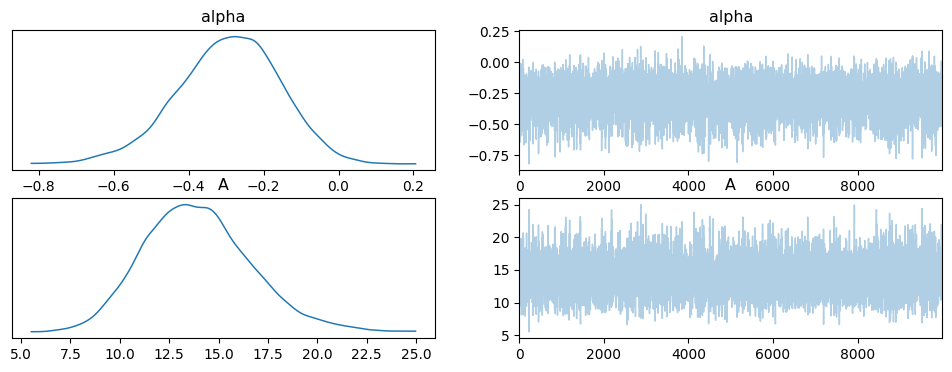

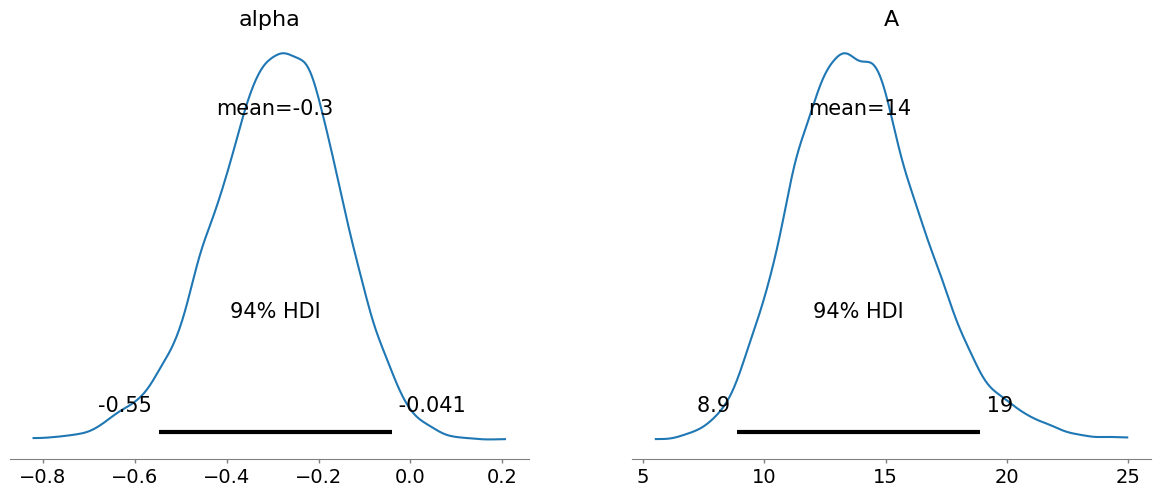

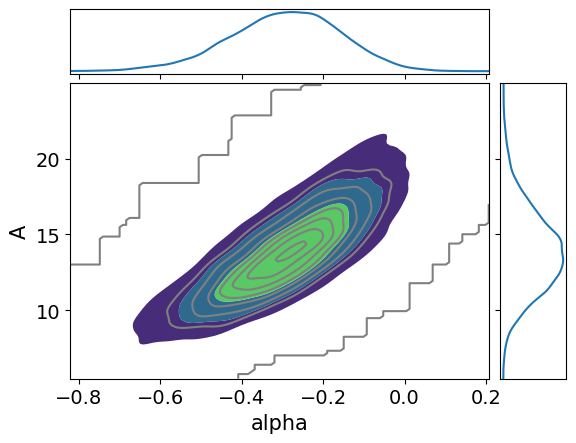

In [ ]:
idata = az.from_dict(
    posterior={
        "alpha": np.asarray(alpha_samples)[None, :],
        "A": np.asarray(A_samples)[None, :],
    }
)
az.plot_trace(idata)
az.plot_posterior(idata)
az.plot_pair(idata, kind="kde", marginals=True)

In [ ]:
alpha_samples = idata.posterior["alpha"].values.flatten()
A_samples = idata.posterior["A"].values.flatten()
n_samples = len(alpha_samples)


def generate_perturbation(alpha, A, n_samples, key): #TODO: not exactly equivalent to what we already have!!!!!
   """
   """
   freqs = jnp.fft.rfftfreq(n_samples)
   # Remove DC mode
   k = freqs.at[0].set(1.0)
   P_k = A * k**alpha
   key_r, key_i = jax.random.split(key)
   real = jax.random.normal(key_r, shape=freqs.shape)
   i = jax.random.normal(key_i, shape=freqs.shape)
   epsilon_k = (real + 1j * i) / jnp.sqrt(2)
   # Fourier coefficients
   x_k = jnp.sqrt(P_k) * epsilon_k
   # Remove mean component
   x_k = x_k.at[0].set(0.0)
   # Back to wavelength space
   perturbation = jnp.fft.irfft(x_k, n=n_samples)
   return perturbation


def fitted_spectrum(alpha_samples, A_samples, band_id_to_zeropoint, instrument: Instrument, key, band: jnp.ndarray, exp_time: jnp.ndarray, sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, source: Source, *args, **kwargs):
   perturbations_key, results_key, key = jax.random.split(key, 3)
   source_values = jnp.asarray(agn.get_values())
   survey_values = instrument.get_values()
   band, exp_time, sky_brightness,PSF_Aeff = jnp.atleast_1d(band), jnp.atleast_1d(exp_time), jnp.atleast_1d(sky_brightness), jnp.atleast_1d(PSF_Aeff)
   obs = jax.vmap(instrument.observe, in_axes=(None, 0, 0, 0, 0, None, None, None, None))
   result = obs(key, band, exp_time, sky_brightness, PSF_Aeff, source, 1, source_values, survey_values)
   true_fl = jnp.squeeze(jax.vmap(convert_to_jy, in_axes=(0, 0, None, None))(result[2], band, band_id_to_zeropoint, instrument.effective_aperture) * 1e9)
   true_err = jnp.squeeze(jax.vmap(convert_to_jy, in_axes=(0, 0, None, None))(result[3], band, band_id_to_zeropoint, instrument.effective_aperture) * 1e9)
   keys = jax.random.split(perturbations_key, len(alpha_samples))
   perturbations = jax.vmap(generate_perturbation, in_axes=(0,0,None,0))(alpha_samples, A_samples, result[2].shape[-1], keys)
   print("result[2]", jnp.mean(result[2]))
   print("result[2]", jnp.mean(result[3]))
   print("result[2]", jnp.mean(true_fl))
   print("result[2]", jnp.mean(true_err))
   print("result[3]", result[3])
   print("true_fl", true_fl.shape)
   print("true_err", true_err.shape)
   print("perturbations", perturbations.shape)
   mean = true_fl * (perturbations + 1)
   return mean + true_err[None, :] * jax.random.normal(key = results_key, shape=np.shape(mean))

pred_samples = fitted_spectrum(alpha_samples, A_samples, zero_points, rubin, jax.random.key(0), band, exp_times, sky_brightnesses, PSF_Aeffs, agn, agn.get_values(), rubin.get_values())

result[2] 0.00013710310423025522
result[2] 3.851464630323429e-05
result[2] 981.8261078908171
result[2] 359.18869984540737
result[3] [4.14356652e-05 3.90651315e-05 5.50916160e-05 5.16941571e-05
 1.37612460e-05 1.39974276e-05 2.73801013e-05 4.38769262e-05
 5.43607224e-05 5.63733754e-05 4.76786110e-05 5.73432369e-05
 5.90101278e-05 1.31351966e-04 6.49307172e-06 6.34655638e-06
 1.59467508e-05 1.54248329e-05 1.14468310e-05 2.73536561e-05
 6.27922171e-05 7.58382484e-05 1.17358387e-05 1.92696633e-05
 5.38441120e-05 5.48875655e-05 8.63478713e-06 2.78645822e-05
 3.95734289e-05 5.60339128e-05 9.94737988e-05 1.17400476e-04
 9.55997187e-05 6.79231109e-05 5.17256637e-05 2.61332840e-05
 5.14902657e-05 3.87116014e-05 4.15279726e-05 3.63963611e-05
 3.37720378e-05 5.52584685e-05 1.02044708e-05 1.80015181e-05
 3.00996257e-05 3.17346944e-05 6.14143206e-05 2.40734398e-05
 3.08495675e-05 3.82459970e-05 3.91830063e-05 5.14577131e-05
 5.01359678e-05 4.84595560e-05 4.69327244e-05 4.56704790e-05
 4.59269930e-0

In [ ]:
posterior_spectra = np.asarray(pred_samples)
plotting_times = jnp.linspace(times[0], times[-1], posterior_spectra.shape[0])


In [ ]:
print(jnp.shape(pred_samples))

(10000, 693)


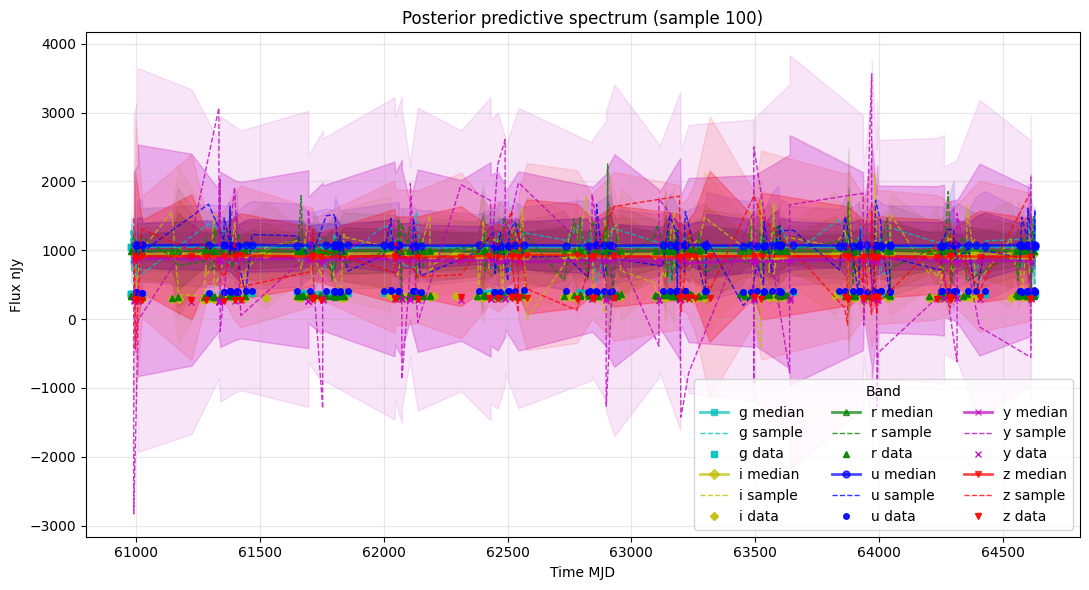

In [ ]:
band_colors = {"u": "#0000FF", "g": "#00BFBF", "r": "#008000", "i": "#BFBF00", "z": "#FF0000", "y": "#BF00BF"}
band_markers = {"u": "o", "g": "s", "r": "^", "i": "D", "z": "v", "y": "x"}

sample_idx = 100
band_strs = np.array([idx_to_bandstr[b.item()] for b in band])
unique_bands = np.unique(band_strs)
fig, ax1 = plt.subplots(figsize=(11, 6))
for b in unique_bands:
    mask = band_strs == b
    samples_band = posterior_spectra[:, mask]
    realization = samples_band[sample_idx]

    q16, q50, q84 = np.percentile(samples_band, [16, 50, 84], axis=0)
    q05, q95 = np.percentile(samples_band, [5, 95], axis=0)
    # in case theyre not ordered, akthough they should
    order = np.argsort(times[mask])
    t = times[mask][order]
    realization = realization[order]
    q16 = q16[order]
    q50 = q50[order]
    q84 = q84[order]
    q05 = q05[order]
    q95 = q95[order]
    color = band_colors[b]
    # 90% credible interval
    ax1.fill_between(
        t,
        q05,
        q95,
        color=color,
        alpha=0.10
    )
    # 68% credible interval
    ax1.fill_between(
        t,
        q16,
        q84,
        color=color,
        alpha=0.25
    )
    # Posterior median
    ax1.plot(
        t,
        q50,
        color=color,
        marker=band_markers[b],
        linestyle="-",
        linewidth=2,
        markersize=5,
        alpha=0.7,
        label=f"{b} median"
    )
    # One posterior predictive realization
    ax1.plot(
        t,
        realization,
        color=color,
        linestyle="--",
        linewidth=1,
        alpha=0.8,
        label=f"{b} sample"
    )
    # Original data
    ax1.plot(
        t,
        flux[mask][order],
        color=color,
        marker=band_markers[b],
        linestyle="none",
        markersize=4,
        alpha=0.9,
        label=f"{b} data"
    )
ax1.set_xlabel("Time MJD")
ax1.set_ylabel("Flux nJy")
ax1.set_title(
    f"Posterior predictive spectrum (sample {sample_idx})"
)
ax1.legend(title="Band", ncol=3)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Cosmographi fit

In [ ]:
import sqlite3
from contextlib import closing
import pandas as pd
import time
np.random.seed(0)
key = jax.random.PRNGKey(0)
colours = ["purple", "green", "red", "teal", "brown", "yellow"]

# Extract survey data from the LSST database
# #####################################################################
survey_path = "/home/renee/renee/opsim/baseline_v5.0.1_10yrs.db"
with closing(sqlite3.connect(survey_path)) as conn:
    query = f"""
        SELECT 
            observationId,
            observationStartMJD,
            visitExposureTime,
            numExposures,
            airmass,
            fieldRA, 
            fieldDec, 
            rotTelPos, 
            rotSkyPos, 
            skyBrightness,
            band,
            filter,
            seeingFwhmEff,
            observation_reason
        FROM observations
        LIMIT 2000;
        """
    survey_df = pd.read_sql_query(query, conn)
print(survey_df)
# WHERE fieldRA = 150.11 AND fieldDec = 2.23
# assert (
#     survey_df["numExposures"].nunique() == 1
# ), "All exposures should have the same number of exposures."
survey_t = survey_df["observationStartMJD"].values
survey_ra = survey_df["fieldRA"].values
survey_dec = survey_df["fieldDec"].values
survey_exp_time = survey_df["visitExposureTime"].values
survey_airmass = survey_df["airmass"].values
survey_sky_brightness = survey_df["skyBrightness"].values
survey_seeing = survey_df["seeingFwhmEff"].values
survey_PSF_Aeff = 4 * np.pi * (survey_seeing / 2.355) ** 2  # convert FWHM to effective area
survey_band = survey_df["band"].values
survey_obsreason = survey_df["observation_reason"].values

print(np.unique(survey_band, return_counts=True))
print(f"T max = {np.max(survey_t)}")
print(f"T min = {np.min(survey_t)}")

from cosmographi.source.agn import AGNSourceLipunova2018
from cosmographi.utils.perturbations import generate_perturbations_vector
from cosmographi.utils.constants import M_sun
# Create source
#####################################################################
perturbations = generate_perturbations_vector (alpha=0.7, n_samples = 4000)
print(perturbations)
C = cp.Cosmology()
source_obj = cp.source_factory(AGNSourceLipunova2018, cp.source.effects.MWExtinction_Calzetti00)
S = source_obj(cosmology=C, A_V_c00mw=0.1, R_V_c00mw=3.1, blackhole_mass=1e8*M_sun, accretion_rate=M_sun*0.5, rin_to_rng=6, inclination_angle=0, perturbations_ar=perturbations, start_time=60900, end_time=65000)
print(S)

#####################################################################
I = cp.RubinObservatory()
I.throughput.trim()
I.throughput.to_dynamic() 
survey_iband, idx_to_bandstr = cp.utils.bandstr_to_bandidx(I.throughput.bands, survey_band, return_dict=True)
nfilter = len(I.throughput.bands)
print(I)
print(I.get_values().shape)

# Generate mock SN
#####################################################################
Nsn = 1
t_range = (np.min(survey_t), np.max(survey_t))
source_t = np.random.uniform(*t_range, Nsn)
S.t0 = source_t
R = cp.RateConst(cosmology=C, z_min=0.01, z_max=1.0, r=1)
key, subkey = jax.random.split(key)
source_z = R.sample_z(subkey, source_t.shape)
S.z = source_z
print(source_z)
chooseraddec = np.random.choice(
    len(survey_ra), Nsn
)  # fixme, not right distribution, but good enough for testing


source_ra, source_dec = cp.utils.sample_near(
    survey_ra[chooseraddec], survey_dec[chooseraddec], radius_deg=2, n=Nsn
)

print("Matching sources to survey...")
source_matches = cp.utils.cross_match_survey_circle(
    source_tmin = np.full(Nsn, np.min(survey_t)),
    source_tmax= np.full(Nsn, np.max(survey_t)),
    source_ra=source_ra,
    source_dec=source_dec,
    survey_t=survey_t,
    survey_ra=survey_ra,
    survey_dec=survey_dec,
    survey_fov=3.5,  # degrees, LSST field of view
)
print(f"Matched {len(source_matches)} sources to survey observations.")
for i in list(source_matches.keys()):
    if len(source_matches[i]) < 5:
        del source_matches[
            i
        ]  # drop sources with fewer than 5 matches, not enough data for lightcurve
        continue
print(f"Matched {len(source_matches)} sources worth examining.")
# print(source_matches)
# TODO: MAKE PRIORS
# P = cp.source.prior.SALT2_SK16Prior()
# x1, c = P.prior_sample(source_t.shape[0])
# S.x1 = x1
# S.c = c
sel_src = np.sort(list(source_matches.keys()))

print(S)
print(S.get_values().shape)
print(sel_src)

# Build params input
#####################################################################
source_values = np.array(S.get_values())
survey_values = np.array(I.get_values())
keys = []
bands = []
exp_times = []
sky_brightnesses = []
PSF_Aeffs = []
obs_t = []
obs_reasons = []
source_params = []
survey_params = []
for i in sel_src:
    _subkeys = jax.random.split(key, len(source_matches[i]) + 1)
    key, subkeys = _subkeys[0], _subkeys[1:]
    keys.append(subkeys)
    bands.append(survey_iband[source_matches[i]])
    exp_times.append(survey_exp_time[source_matches[i]])
    sky_brightnesses.append(survey_sky_brightness[source_matches[i]])
    PSF_Aeffs.append(survey_PSF_Aeff[source_matches[i]])
    obs_t.append(survey_t[source_matches[i]])
    obs_reasons.append(survey_obsreason[source_matches[i]])
    source_params.append(jnp.repeat(source_values[i][None, :], len(source_matches[i]), axis=0))
    survey_params.append(survey_airmass[source_matches[i]][:, None])  # shape (n_obs, 1)

keys = jnp.array(np.concatenate(keys))
bands = jnp.array(np.concatenate(bands))
exp_times = jnp.array(np.concatenate(exp_times))
sky_brightnesses = jnp.array(np.concatenate(sky_brightnesses))
PSF_Aeffs = jnp.array(np.concatenate(PSF_Aeffs))
obs_t = jnp.array(np.concatenate(obs_t))
obs_reasons = np.array(np.concatenate(obs_reasons))
source_params = jnp.array(np.concatenate(source_params, axis=0))
survey_params = jnp.array(np.concatenate(survey_params, axis=0))
print("Keys shape:", keys.shape)
print("Bands shape:", bands.shape)
print("Exp times shape:", exp_times.shape)
print("Source params shape:", source_params.shape)
print("Survey params shape:", survey_params.shape)

print(sel_src)

# Run mock survey lightcurves
#####################################################################
vobs = jax.jit(jax.vmap(I.observe, in_axes=(0, 0, 0, 0, 0, None, 0, 0, 0)), static_argnums=(5,))
start = time.time()
LCs = []
nobs = len(keys)

#TODO: had to lower, what is eating up my memory??

batch_size = 10

print("batch_size =", batch_size)
i = 0
print("keys", keys[i:i+batch_size].shape)
print("bands", bands[i:i+batch_size].shape)
print("exp_times", exp_times[i:i+batch_size].shape)
print("sky_brightnesses", sky_brightnesses[i:i+batch_size].shape)
print("PSF_Aeffs", PSF_Aeffs[i:i+batch_size].shape)
print("obs_t", obs_t[i:i+batch_size].shape)
print("source_params", source_params[i:i+batch_size].shape)
print("survey_params", survey_params[i:i+batch_size].shape)

for i in range(0, nobs, batch_size):
    LCs.append(
        vobs(
            keys[i : i + batch_size],
            bands[i : i + batch_size],
            exp_times[i : i + batch_size],
            sky_brightnesses[i : i + batch_size],
            PSF_Aeffs[i : i + batch_size],
            S,
            obs_t[i : i + batch_size],
            source_params[i : i + batch_size],  
            survey_params[i : i + batch_size],
        )
    )
LCs = tuple(
    jnp.concatenate(tuple(LCs[i][f] for i in range(len(LCs))), axis=0) for f in range(len(LCs[0]))
)

seli = sel_src[0]
spot = sum(len(source_matches[i]) for i in sel_src if i < seli)
times = obs_t[spot : spot + len(source_matches[seli])]
lc_obs = LCs[0][spot : spot + len(source_matches[seli])]

      observationId  observationStartMJD  visitExposureTime  numExposures  \
0                 0         60981.002252               15.0             1   
1                 1         60981.002498               15.0             1   
...             ...                  ...                ...           ...   
1998           1998         60991.340945               30.0             1   
1999           1999         60991.341370               30.0             1   

       airmass     fieldRA   fieldDec  rotTelPos   rotSkyPos  skyBrightness  \
0     1.931643  263.940171 -25.278365  43.954310  337.594539      18.554474   
1     2.075088  262.851107 -22.591159  43.880901  339.357181      18.424405   
...        ...         ...        ...        ...         ...            ...   
1998  1.992595   18.394858 -72.598011 -21.044592   26.174793      19.656694   
1999  2.200240    9.141902 -71.313160 -21.029753   35.525118      19.568774   

     band filter  seeingFwhmEff observation_reason  
0       r

In [25]:
agn2 = AGNSourceLipunova2018_invariable(blackhole_mass=S.blackhole_mass, accretion_rate=S.accretion_rate, inclination_angle=S.inclination_angle, rin_to_rng=S.rin_to_rng)
agn2.cosmology = Cosmology()
agn2.z = source_z
agn2.t0 = times[0]
agn2.mu = agn2.cosmology.distance_modulus(source_z)
y_mean = jnp.mean(lc_obs)
y = lc_obs / y_mean

key = jax.random.key(42)
initial_position = {
    "alpha": jnp.array(1.7),
    "A": jnp.array(5.0),
}

band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(I.throughput.bands, bands, return_dict=True)
def create_band_id_to_zero(idx_to_bandstr, band_str_to_zero):
        dict = {}
        for key in idx_to_bandstr:
            dict[key] = band_str_to_zero[idx_to_bandstr[key]]
        return dict
band_str_to_zero = {'u': 26.52, 'g': 28.51, 'r': 28.36, 'i': 28.17, 'z': 27.78, 'y': 26.82}
band_id_to_zero = create_band_id_to_zero(idx_to_bandstr, band_str_to_zero)
zero_points = jnp.asarray([band_id_to_zero[i] for i in range(len(band_id_to_zero))])
target_log_posterior = partial(
    log_posterior,
    y=y,
    instrument=I,
    band_id_to_zeropoint=zero_points,
    key=key,
    band=bands,
    exp_time=exp_times,
    sky_brightness=sky_brightnesses,
    PSF_Aeff=PSF_Aeffs,
    source=agn2,
)

warmup = bx.window_adaptation(bx.hmc, target_log_posterior, num_integration_steps=1000,)
adaptation_results, adaptation_info = warmup.run(key, initial_position)
kernel = bx.hmc(target_log_posterior, **adaptation_results.parameters).step
num_samples = 10000
keys = jax.random.split(key, num_samples)
def one_step(state, key):
    state, info = kernel(key, state)
    return state, state
@jax.jit
def run_chain(initial_state, keys):
    return jax.lax.scan(one_step, initial_state, keys)
final_state, history = run_chain(adaptation_results.state, keys)
jax.block_until_ready(history.position["alpha"])
jax.block_until_ready(history.position["A"])
alpha_samples = np.asarray(history.position["alpha"])
A_samples = np.asarray(history.position["A"])

TypeError: log_posterior() got an unexpected keyword argument 'instrument'

In [ ]:
idata = az.from_dict(
    posterior={
        "alpha": np.asarray(alpha_samples)[None, :],
        "A": np.asarray(A_samples)[None, :],
    }
)

In [ ]:
print(type(alpha_samples))
print(type(A_samples))
print(alpha_samples.shape)
print(A_samples.shape)
print(alpha_samples.dtype)
print(A_samples.dtype)
print(alpha_samples.nbytes / 1024**2, "MB")
print(A_samples.nbytes / 1024**2, "MB")
a = np.asarray(alpha_samples)
b = np.asarray(A_samples)
print(type(a))
print(a.shape, a.dtype)
print(type(b))
print(b.shape, b.dtype)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(10000,)
(10000,)
float64
float64
0.0762939453125 MB
0.0762939453125 MB
<class 'numpy.ndarray'>
(10000,) float64
<class 'numpy.ndarray'>
(10000,) float64


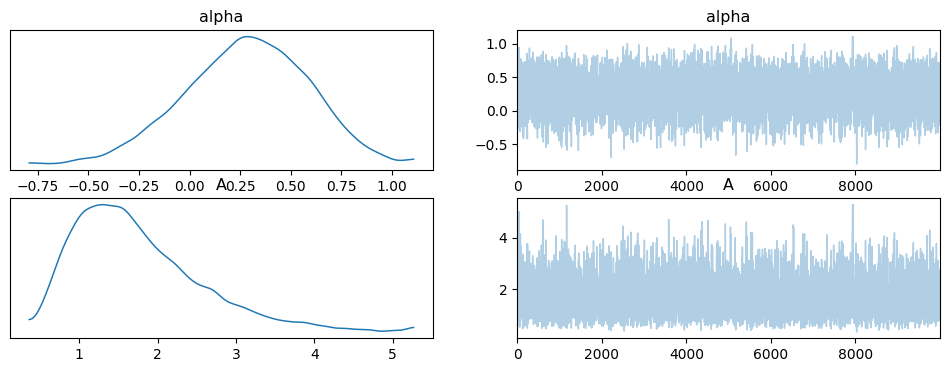

In [ ]:
az.plot_trace(idata)
plt.show()

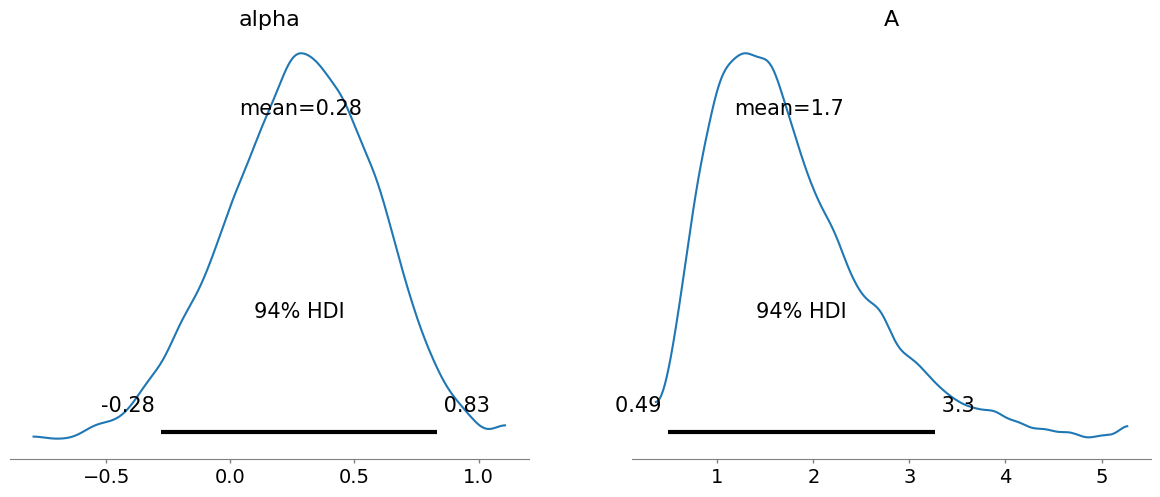

In [ ]:
az.plot_posterior(idata)
plt.show()

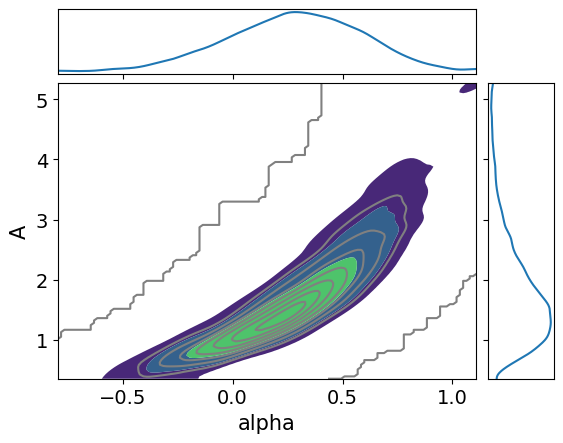

In [ ]:
az.plot_pair(idata, kind="kde", marginals=True)
plt.show()

In [ ]:

alpha_samples = idata.posterior["alpha"].values.flatten()
A_samples = idata.posterior["A"].values.flatten()
n_samples = len(alpha_samples)
pred_samples = fitted_spectrum(alpha_samples, A_samples, y

result[2] 0.00263438737522316
result[2] 3.9720169807816455e-05
result[2] 15096.077937213136
result[2] 248.79712711986235
result[3] [4.68870041e-05 5.35445621e-05 5.14817285e-05 3.34589035e-05
 3.21631603e-05 3.18577785e-05 5.83475837e-05 2.49725936e-05
 2.47682138e-05]
true_fl (9,)
true_err (9,)
perturbations (10000, 9)


In [ ]:
posterior_spectra = np.asarray(pred_samples)
plotting_times = jnp.linspace(times[0], times[-1], posterior_spectra.shape[0])


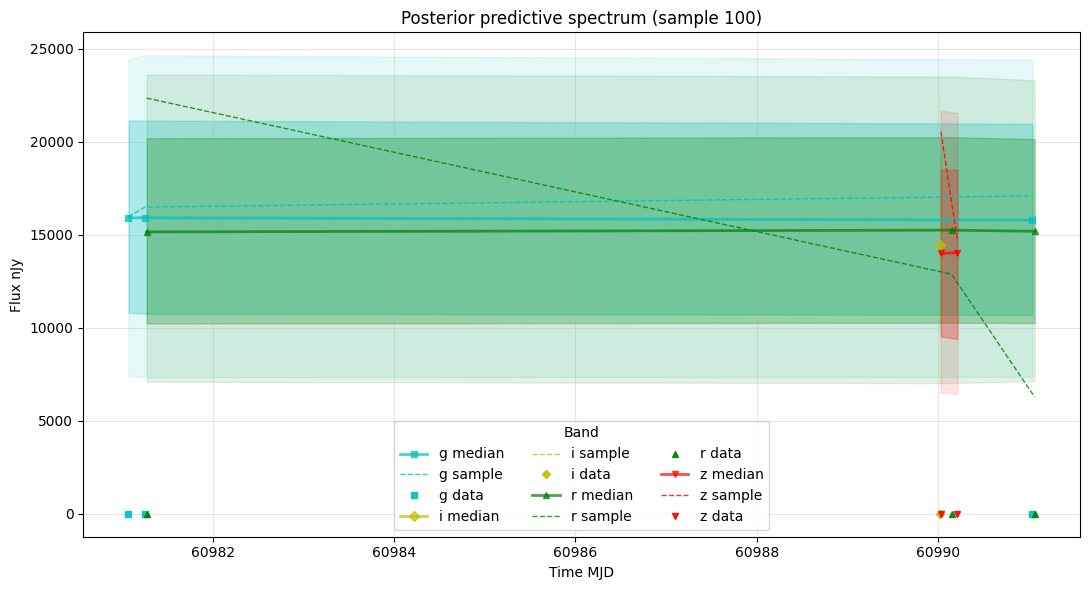

In [ ]:
band_colors = {"u": "#0000FF", "g": "#00BFBF", "r": "#008000", "i": "#BFBF00", "z": "#FF0000", "y": "#BF00BF"}
band_markers = {"u": "o", "g": "s", "r": "^", "i": "D", "z": "v", "y": "x"}

sample_idx = 100
band_strs = np.array([idx_to_bandstr[b.item()] for b in bands])
unique_bands = np.unique(band_strs)
fig, ax1 = plt.subplots(figsize=(11, 6))
for b in unique_bands:
    mask = band_strs == b
    samples_band = posterior_spectra[:, mask]
    realization = samples_band[sample_idx]

    q16, q50, q84 = np.percentile(samples_band, [16, 50, 84], axis=0)
    q05, q95 = np.percentile(samples_band, [5, 95], axis=0)
    # in case theyre not ordered, akthough they should
    order = np.argsort(times[mask])
    t = times[mask][order]
    realization = realization[order]
    q16 = q16[order]
    q50 = q50[order]
    q84 = q84[order]
    q05 = q05[order]
    q95 = q95[order]
    color = band_colors[b]
    # 90% credible interval
    ax1.fill_between(
        t,
        q05,
        q95,
        color=color,
        alpha=0.10
    )
    # 68% credible interval
    ax1.fill_between(
        t,
        q16,
        q84,
        color=color,
        alpha=0.25
    )
    # Posterior median
    ax1.plot(
        t,
        q50,
        color=color,
        marker=band_markers[b],
        linestyle="-",
        linewidth=2,
        markersize=5,
        alpha=0.7,
        label=f"{b} median"
    )
    # One posterior predictive realization
    ax1.plot(
        t,
        realization,
        color=color,
        linestyle="--",
        linewidth=1,
        alpha=0.8,
        label=f"{b} sample"
    )
    # Original data
    ax1.plot(
        t,
        lc_obs[mask][order],
        color=color,
        marker=band_markers[b],
        linestyle="none",
        markersize=4,
        alpha=0.9,
        label=f"{b} data"
    )
ax1.set_xlabel("Time MJD")
ax1.set_ylabel("Flux nJy")
ax1.set_title(
    f"Posterior predictive spectrum (sample {sample_idx})"
)
ax1.legend(title="Band", ncol=3)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Cosmographi fit with a simpler model

In [26]:
def halfnormal_logpdf(x, scale):
    return jnp.where(x > 0,jnp.log(2.0) + stats.norm.logpdf(x, loc=0.0, scale=scale),-jnp.inf)

In [40]:
def generate_perturbation(alpha, A, n_samples, key): #TODO: not exactly equivalent to what we already have!!!!!
   """
   """
   freqs = jnp.fft.rfftfreq(n_samples)
   # Remove DC mode
   k = freqs.at[0].set(1.0)
   P_k = A * k**alpha
   key_r, key_i = jax.random.split(key)
   real = jax.random.normal(key_r, shape=freqs.shape)
   i = jax.random.normal(key_i, shape=freqs.shape)
   epsilon_k = (real + 1j * i) / jnp.sqrt(2)
   # Fourier coefficients
   x_k = jnp.sqrt(P_k) * epsilon_k
   # Remove mean component
   x_k = x_k.at[0].set(0.0)
   # Back to wavelength space
   perturbation = jnp.fft.irfft(x_k, n=n_samples)
   return perturbation

In [30]:
def log_prior_alpha(evaluate_at: float) -> float:
    """ Return the log probability density of the prior on alpha evaluated at <evaluate_at>.
    alpha ~ Normal(0, 5)
    """
    return stats.norm.logpdf(evaluate_at, loc=1.7, scale=5.0)

def log_prior_A(evaluate_at: float) -> float:
    """ Return the log probability density of the prior on A evaluated at <evaluate_at>.
    A ~ Normal(0, 5)
    """
    return halfnormal_logpdf(evaluate_at, 10)

@jax.jit
def power_spectrum_log_likelihood(x: jnp.ndarray, params, var_floor: float = 1e-8) -> jnp.ndarray:
    """
    Evaluates the log-prior probability density of a 1D real-valued array x,
    assuming a power-law power spectrum P(k) = amplitude * k^alpha.

    Args:
        x: 1D array of real-valued data.
        alpha: The power law slope of the spectrum.
        amplitude: Scaling factor for the power spectrum.
        var_floor: A floor applied to the total variance to prevent division
                   by zero and ensure numerical stability in gradients.

    Returns:
        log_prob: The scalar log-probability density.
    """
    alpha = params["alpha"]
    A = params["A"]

    N = x.shape[0]

    # 1. Transform to frequency domain
    x_k = jnp.fft.rfft(x)
    freqs = jnp.fft.rfftfreq(N)

    # 2. Isolate non-zero frequencies
    # The DC component (k=0) is excluded to avoid singular values.
    # It is typically assumed the signal is mean-centered, or the mean
    # is modeled with a separate uniform/normal prior.
    k_nz = freqs[1:]
    x_k_nz = x_k[1:]

    # 3. Compute expected power spectrum variance
    # Applying the variance floor prevents the variance from dropping to zero
    # (e.g., at high frequencies if alpha < 0) which would cause log(0) NaNs.
    P_k = A * (k_nz ** alpha) + var_floor

    # 4. Calculate log probability of the Fourier modes
    # The rfft coefficients for k > 0 are independent complex Gaussians.
    # The variance of these complex modes is proportional to P(k).
    power_x = jnp.abs(x_k_nz)**2

    # Log PDF of a complex Gaussian: -|z|^2 / Var - log(pi * Var)
    log_prob_modes = -(power_x / P_k) - jnp.log(jnp.pi * P_k)

    # Sum over all independent modes to get the total log-prior
    return jnp.sum(log_prob_modes)

def log_prior(params):
    alpha = params["alpha"]
    A = params["A"]
    lp = log_prior_alpha(alpha) + log_prior_A(A) 
    return lp


def log_likelihood(params, y):
    log_shape = power_spectrum_log_likelihood(y, params)
    return log_shape 

def log_posterior(params, y):
    return log_likelihood(params, y) + log_prior(params)

In [28]:
import sqlite3
from contextlib import closing
import pandas as pd
import time
np.random.seed(0)
key = jax.random.PRNGKey(0)
colours = ["purple", "green", "red", "teal", "brown", "yellow"]

# Extract survey data from the LSST database
# #####################################################################
survey_path = "/home/renee/renee/opsim/baseline_v5.0.1_10yrs.db"
with closing(sqlite3.connect(survey_path)) as conn:
    query = f"""
        SELECT 
            observationId,
            observationStartMJD,
            visitExposureTime,
            numExposures,
            airmass,
            fieldRA, 
            fieldDec, 
            rotTelPos, 
            rotSkyPos, 
            skyBrightness,
            band,
            filter,
            seeingFwhmEff,
            observation_reason
        FROM observations
        LIMIT 2000;
        """
    survey_df = pd.read_sql_query(query, conn)
print(survey_df)
# WHERE fieldRA = 150.11 AND fieldDec = 2.23
# assert (
#     survey_df["numExposures"].nunique() == 1
# ), "All exposures should have the same number of exposures."
survey_t = survey_df["observationStartMJD"].values
survey_ra = survey_df["fieldRA"].values
survey_dec = survey_df["fieldDec"].values
survey_exp_time = survey_df["visitExposureTime"].values
survey_airmass = survey_df["airmass"].values
survey_sky_brightness = survey_df["skyBrightness"].values
survey_seeing = survey_df["seeingFwhmEff"].values
survey_PSF_Aeff = 4 * np.pi * (survey_seeing / 2.355) ** 2  # convert FWHM to effective area
survey_band = survey_df["band"].values
survey_obsreason = survey_df["observation_reason"].values

print(np.unique(survey_band, return_counts=True))
print(f"T max = {np.max(survey_t)}")
print(f"T min = {np.min(survey_t)}")

from cosmographi.source.agn import AGNSourceLipunova2018
from cosmographi.utils.perturbations import generate_perturbations_vector
from cosmographi.utils.constants import M_sun
# Create source
#####################################################################
perturbations = generate_perturbations_vector (alpha=0.7, n_samples = 4000)
print(perturbations)
C = cp.Cosmology()
source_obj = cp.source_factory(AGNSourceLipunova2018, cp.source.effects.MWExtinction_Calzetti00)
S = source_obj(cosmology=C, A_V_c00mw=0.1, R_V_c00mw=3.1, blackhole_mass=1e8*M_sun, accretion_rate=M_sun*0.5, rin_to_rng=6, inclination_angle=0, perturbations_ar=perturbations, start_time=60900, end_time=65000)
print(S)

#####################################################################
I = cp.RubinObservatory()
I.throughput.trim()
I.throughput.to_dynamic() 
survey_iband, idx_to_bandstr = cp.utils.bandstr_to_bandidx(I.throughput.bands, survey_band, return_dict=True)
nfilter = len(I.throughput.bands)
print(I)
print(I.get_values().shape)

# Generate mock SN
#####################################################################
Nsn = 1
t_range = (np.min(survey_t), np.max(survey_t))
source_t = np.random.uniform(*t_range, Nsn)
S.t0 = source_t
R = cp.RateConst(cosmology=C, z_min=0.01, z_max=1.0, r=1)
key, subkey = jax.random.split(key)
source_z = R.sample_z(subkey, source_t.shape)
S.z = source_z
print(source_z)
chooseraddec = np.random.choice(
    len(survey_ra), Nsn
)  # fixme, not right distribution, but good enough for testing


source_ra, source_dec = cp.utils.sample_near(
    survey_ra[chooseraddec], survey_dec[chooseraddec], radius_deg=2, n=Nsn
)

print("Matching sources to survey...")
source_matches = cp.utils.cross_match_survey_circle(
    source_tmin = np.full(Nsn, np.min(survey_t)),
    source_tmax= np.full(Nsn, np.max(survey_t)),
    source_ra=source_ra,
    source_dec=source_dec,
    survey_t=survey_t,
    survey_ra=survey_ra,
    survey_dec=survey_dec,
    survey_fov=3.5,  # degrees, LSST field of view
)
print(f"Matched {len(source_matches)} sources to survey observations.")
for i in list(source_matches.keys()):
    if len(source_matches[i]) < 5:
        del source_matches[
            i
        ]  # drop sources with fewer than 5 matches, not enough data for lightcurve
        continue
print(f"Matched {len(source_matches)} sources worth examining.")
# print(source_matches)
# TODO: MAKE PRIORS
# P = cp.source.prior.SALT2_SK16Prior()
# x1, c = P.prior_sample(source_t.shape[0])
# S.x1 = x1
# S.c = c
sel_src = np.sort(list(source_matches.keys()))

print(S)
print(S.get_values().shape)
print(sel_src)

# Build params input
#####################################################################
source_values = np.array(S.get_values())
survey_values = np.array(I.get_values())
keys = []
bands = []
exp_times = []
sky_brightnesses = []
PSF_Aeffs = []
obs_t = []
obs_reasons = []
source_params = []
survey_params = []
for i in sel_src:
    _subkeys = jax.random.split(key, len(source_matches[i]) + 1)
    key, subkeys = _subkeys[0], _subkeys[1:]
    keys.append(subkeys)
    bands.append(survey_iband[source_matches[i]])
    exp_times.append(survey_exp_time[source_matches[i]])
    sky_brightnesses.append(survey_sky_brightness[source_matches[i]])
    PSF_Aeffs.append(survey_PSF_Aeff[source_matches[i]])
    obs_t.append(survey_t[source_matches[i]])
    obs_reasons.append(survey_obsreason[source_matches[i]])
    source_params.append(jnp.repeat(source_values[i][None, :], len(source_matches[i]), axis=0))
    survey_params.append(survey_airmass[source_matches[i]][:, None])  # shape (n_obs, 1)

keys = jnp.array(np.concatenate(keys))
bands = jnp.array(np.concatenate(bands))
exp_times = jnp.array(np.concatenate(exp_times))
sky_brightnesses = jnp.array(np.concatenate(sky_brightnesses))
PSF_Aeffs = jnp.array(np.concatenate(PSF_Aeffs))
obs_t = jnp.array(np.concatenate(obs_t))
obs_reasons = np.array(np.concatenate(obs_reasons))
source_params = jnp.array(np.concatenate(source_params, axis=0))
survey_params = jnp.array(np.concatenate(survey_params, axis=0))
print("Keys shape:", keys.shape)
print("Bands shape:", bands.shape)
print("Exp times shape:", exp_times.shape)
print("Source params shape:", source_params.shape)
print("Survey params shape:", survey_params.shape)

print(sel_src)

# Run mock survey lightcurves
#####################################################################
vobs = jax.jit(jax.vmap(I.observe, in_axes=(0, 0, 0, 0, 0, None, 0, 0, 0)), static_argnums=(5,))
start = time.time()
LCs = []
nobs = len(keys)

#TODO: had to lower, what is eating up my memory??

batch_size = 10

print("batch_size =", batch_size)
i = 0
print("keys", keys[i:i+batch_size].shape)
print("bands", bands[i:i+batch_size].shape)
print("exp_times", exp_times[i:i+batch_size].shape)
print("sky_brightnesses", sky_brightnesses[i:i+batch_size].shape)
print("PSF_Aeffs", PSF_Aeffs[i:i+batch_size].shape)
print("obs_t", obs_t[i:i+batch_size].shape)
print("source_params", source_params[i:i+batch_size].shape)
print("survey_params", survey_params[i:i+batch_size].shape)

for i in range(0, nobs, batch_size):
    LCs.append(
        vobs(
            keys[i : i + batch_size],
            bands[i : i + batch_size],
            exp_times[i : i + batch_size],
            sky_brightnesses[i : i + batch_size],
            PSF_Aeffs[i : i + batch_size],
            S,
            obs_t[i : i + batch_size],
            source_params[i : i + batch_size],  
            survey_params[i : i + batch_size],
        )
    )
LCs = tuple(
    jnp.concatenate(tuple(LCs[i][f] for i in range(len(LCs))), axis=0) for f in range(len(LCs[0]))
)

seli = sel_src[0]
spot = sum(len(source_matches[i]) for i in sel_src if i < seli)
times = obs_t[spot : spot + len(source_matches[seli])]
lc_obs = LCs[0][spot : spot + len(source_matches[seli])]

      observationId  observationStartMJD  visitExposureTime  numExposures  \
0                 0         60981.002252               15.0             1   
1                 1         60981.002498               15.0             1   
...             ...                  ...                ...           ...   
1998           1998         60991.340945               30.0             1   
1999           1999         60991.341370               30.0             1   

       airmass     fieldRA   fieldDec  rotTelPos   rotSkyPos  skyBrightness  \
0     1.931643  263.940171 -25.278365  43.954310  337.594539      18.554474   
1     2.075088  262.851107 -22.591159  43.880901  339.357181      18.424405   
...        ...         ...        ...        ...         ...            ...   
1998  1.992595   18.394858 -72.598011 -21.044592   26.174793      19.656694   
1999  2.200240    9.141902 -71.313160 -21.029753   35.525118      19.568774   

     band filter  seeingFwhmEff observation_reason  
0       r

In [31]:
y_mean = jnp.mean(lc_obs)
y = lc_obs / y_mean - 1

agn2 = AGNSourceLipunova2018_invariable(blackhole_mass=S.blackhole_mass, accretion_rate=S.accretion_rate, inclination_angle=S.inclination_angle, rin_to_rng=S.rin_to_rng)
agn2.cosmology = Cosmology()
agn2.z = source_z
agn2.t0 = times[0]
agn2.mu = agn2.cosmology.distance_modulus(source_z)

key = jax.random.key(42)
initial_position = {
    "alpha": jnp.array(1.7),
    "A": jnp.array(5.0),
}

band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(I.throughput.bands, bands, return_dict=True)
def create_band_id_to_zero(idx_to_bandstr, band_str_to_zero):
        dict = {}
        for key in idx_to_bandstr:
            dict[key] = band_str_to_zero[idx_to_bandstr[key]]
        return dict
band_str_to_zero = {'u': 26.52, 'g': 28.51, 'r': 28.36, 'i': 28.17, 'z': 27.78, 'y': 26.82}
band_id_to_zero = create_band_id_to_zero(idx_to_bandstr, band_str_to_zero)
zero_points = jnp.asarray([band_id_to_zero[i] for i in range(len(band_id_to_zero))])
target_log_posterior = partial(log_posterior, y=y)

warmup = bx.window_adaptation(bx.hmc, target_log_posterior, num_integration_steps=1000,)
adaptation_results, adaptation_info = warmup.run(key, initial_position)
kernel = bx.hmc(target_log_posterior, **adaptation_results.parameters).step
num_samples = 10000
keys = jax.random.split(key, num_samples)
def one_step(state, key):
    state, info = kernel(key, state)
    return state, state
@jax.jit
def run_chain(initial_state, keys):
    return jax.lax.scan(one_step, initial_state, keys)
final_state, history = run_chain(adaptation_results.state, keys)
jax.block_until_ready(history.position["alpha"])
jax.block_until_ready(history.position["A"])
alpha_samples = np.asarray(history.position["alpha"])
A_samples = np.asarray(history.position["A"])

In [32]:
idata = az.from_dict(
    posterior={
        "alpha": np.asarray(alpha_samples)[None, :],
        "A": np.asarray(A_samples)[None, :],
    }
)

In [33]:
print(type(alpha_samples))
print(type(A_samples))
print(alpha_samples.shape)
print(A_samples.shape)
print(alpha_samples.dtype)
print(A_samples.dtype)
print(alpha_samples.nbytes / 1024**2, "MB")
print(A_samples.nbytes / 1024**2, "MB")
a = np.asarray(alpha_samples)
b = np.asarray(A_samples)
print(type(a))
print(a.shape, a.dtype)
print(type(b))
print(b.shape, b.dtype)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(10000,)
(10000,)
float64
float64
0.0762939453125 MB
0.0762939453125 MB
<class 'numpy.ndarray'>
(10000,) float64
<class 'numpy.ndarray'>
(10000,) float64


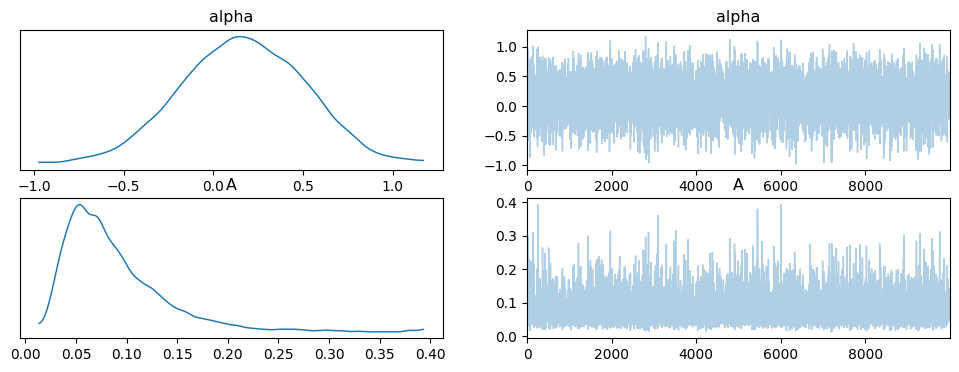

In [34]:
az.plot_trace(idata)
plt.show()

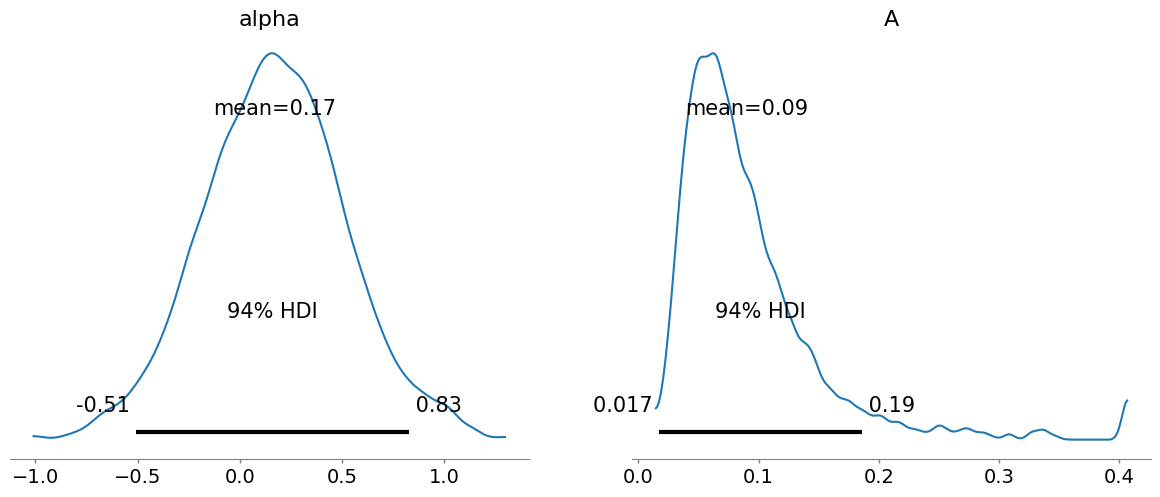

In [ ]:
az.plot_posterior(idata)
plt.show()

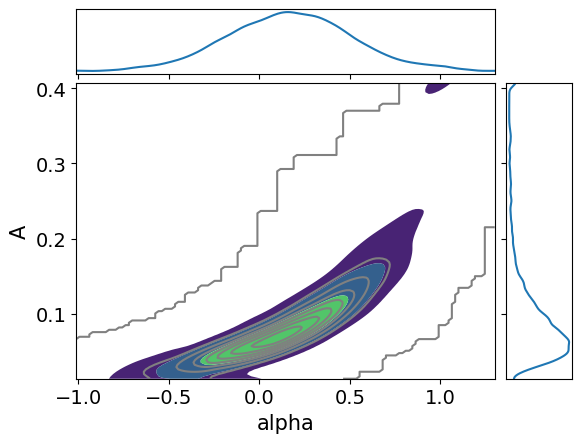

In [ ]:
az.plot_pair(idata, kind="kde", marginals=True)
plt.show()

In [52]:
def fitted_spectrum_simple(alpha_samples, A_samples, y_mean, n_samples):
   perturbations = jax.vmap(generate_perturbation, in_axes=(0,0,None,0))(alpha_samples, A_samples, n_samples, keys)
   return (perturbations + 1) * y_mean

In [53]:

alpha_samples = idata.posterior["alpha"].values.flatten()
A_samples = idata.posterior["A"].values.flatten()
pred_samples = fitted_spectrum_simple(alpha_samples, A_samples, y_mean, 9)

In [54]:
posterior_spectra = np.asarray(pred_samples)
plotting_times = jnp.linspace(times[0], times[-1], posterior_spectra.shape[0])
print(posterior_spectra.shape)

(10000, 9)


posterior_spectra: (10000, 9)
band_strs: (9,)
mask: (9,)


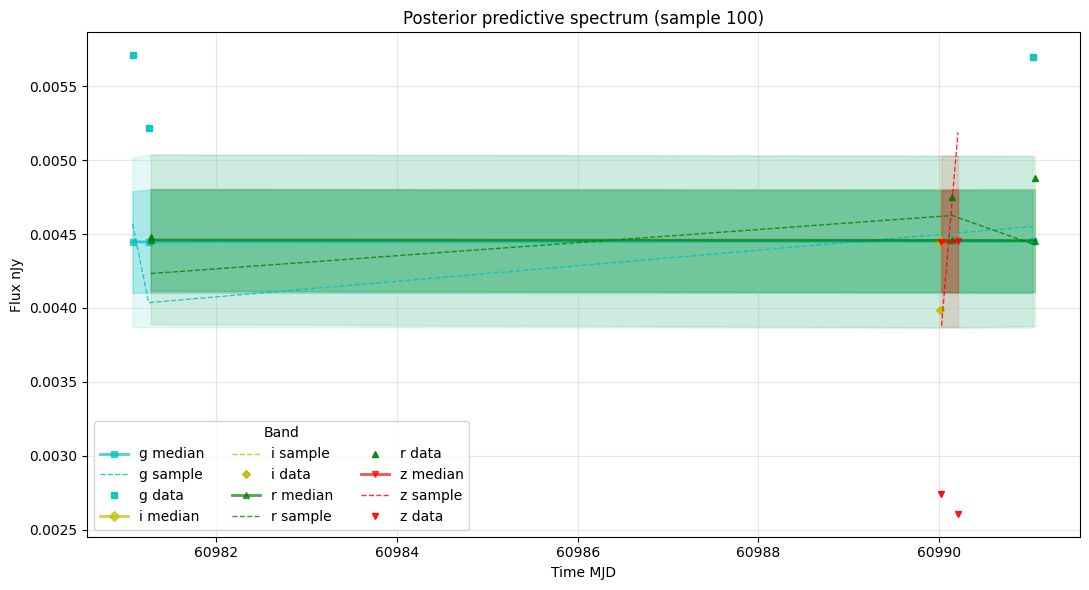

In [55]:
band_colors = {"u": "#0000FF", "g": "#00BFBF", "r": "#008000", "i": "#BFBF00", "z": "#FF0000", "y": "#BF00BF"}
band_markers = {"u": "o", "g": "s", "r": "^", "i": "D", "z": "v", "y": "x"}

sample_idx = 100
band_strs = np.array([idx_to_bandstr[b.item()] for b in bands])
unique_bands = np.unique(band_strs)
fig, ax1 = plt.subplots(figsize=(11, 6))

print("posterior_spectra:", posterior_spectra.shape)
print("band_strs:", band_strs.shape)
print("mask:", mask.shape)

for b in unique_bands:
    mask = band_strs == b
    samples_band = posterior_spectra[:, mask]
    realization = samples_band[sample_idx]

    q16, q50, q84 = np.percentile(samples_band, [16, 50, 84], axis=0)
    q05, q95 = np.percentile(samples_band, [5, 95], axis=0)
    # in case theyre not ordered, akthough they should
    order = np.argsort(times[mask])
    t = times[mask][order]
    realization = realization[order]
    q16 = q16[order]
    q50 = q50[order]
    q84 = q84[order]
    q05 = q05[order]
    q95 = q95[order]
    color = band_colors[b]
    # 90% credible interval
    ax1.fill_between(
        t,
        q05,
        q95,
        color=color,
        alpha=0.10
    )
    # 68% credible interval
    ax1.fill_between(
        t,
        q16,
        q84,
        color=color,
        alpha=0.25
    )
    # Posterior median
    ax1.plot(
        t,
        q50,
        color=color,
        marker=band_markers[b],
        linestyle="-",
        linewidth=2,
        markersize=5,
        alpha=0.7,
        label=f"{b} median"
    )
    # One posterior predictive realization
    ax1.plot(
        t,
        realization,
        color=color,
        linestyle="--",
        linewidth=1,
        alpha=0.8,
        label=f"{b} sample"
    )
    # Original data
    ax1.plot(
        t,
        lc_obs[mask][order],
        color=color,
        marker=band_markers[b],
        linestyle="none",
        markersize=4,
        alpha=0.9,
        label=f"{b} data"
    )
ax1.set_xlabel("Time MJD")
ax1.set_ylabel("Flux nJy")
ax1.set_title(
    f"Posterior predictive spectrum (sample {sample_idx})"
)
ax1.legend(title="Band", ncol=3)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Fine model

In [79]:
def halfnormal_logpdf(x, scale):
    return jnp.where(x > 0,jnp.log(2.0) + stats.norm.logpdf(x, loc=0.0, scale=scale),-jnp.inf)

In [80]:
def generate_perturbation(alpha, A, n_samples, key): #TODO: not exactly equivalent to what we already have!!!!!
   """
   """
   freqs = jnp.fft.rfftfreq(n_samples)
   # Remove DC mode
   k = freqs.at[0].set(1.0)
   P_k = A * k**alpha
   key_r, key_i = jax.random.split(key)
   real = jax.random.normal(key_r, shape=freqs.shape)
   i = jax.random.normal(key_i, shape=freqs.shape)
   epsilon_k = (real + 1j * i) / jnp.sqrt(2)
   # Fourier coefficients
   x_k = jnp.sqrt(P_k) * epsilon_k
   # Remove mean component
   x_k = x_k.at[0].set(0.0)
   # Back to wavelength space
   perturbation = jnp.fft.irfft(x_k, n=n_samples)
   return perturbation

In [81]:
def log_prior_alpha(evaluate_at: float) -> float:
    """ Return the log probability density of the prior on alpha evaluated at <evaluate_at>.
    alpha ~ Normal(0, 5)
    """
    return stats.norm.logpdf(evaluate_at, loc=1.7, scale=5.0)

def log_prior_A(evaluate_at: float) -> float:
    """ Return the log probability density of the prior on A evaluated at <evaluate_at>.
    A ~ HalfNormal(10)
    """
    return halfnormal_logpdf(evaluate_at, 10)

def log_prior_sigma(evaluate_at: float) -> float:
    """ Return the log probability density of the prior on A evaluated at <evaluate_at>.
    A ~ HalfNormal(10)
    """
    return halfnormal_logpdf(evaluate_at, 10)

@jax.jit
def power_spectrum_log_prior(alpha, A, x, var_floor: float = 1e-8) -> jnp.ndarray:
    """
    Evaluates the log-prior probability density of a 1D real-valued array x,
    assuming a power-law power spectrum P(k) = amplitude * k^alpha.

    Args:
        x: 1D array of real-valued data.
        alpha: The power law slope of the spectrum.
        amplitude: Scaling factor for the power spectrum.
        var_floor: A floor applied to the total variance to prevent division
                   by zero and ensure numerical stability in gradients.

    Returns:
        log_prob: The scalar log-probability density.
    """
    N = x.shape[0]

    # 1. Transform to frequency domain
    x_k = jnp.fft.rfft(x)
    freqs = jnp.fft.rfftfreq(N)

    # 2. Isolate non-zero frequencies
    # The DC component (k=0) is excluded to avoid singular values.
    # It is typically assumed the signal is mean-centered, or the mean
    # is modeled with a separate uniform/normal prior.
    k_nz = freqs[1:]
    x_k_nz = x_k[1:]

    # 3. Compute expected power spectrum variance
    # Applying the variance floor prevents the variance from dropping to zero
    # (e.g., at high frequencies if alpha < 0) which would cause log(0) NaNs.
    P_k = A * (k_nz ** alpha) + var_floor

    # 4. Calculate log probability of the Fourier modes
    # The rfft coefficients for k > 0 are independent complex Gaussians.
    # The variance of these complex modes is proportional to P(k).
    power_x = jnp.abs(x_k_nz)**2

    # Log PDF of a complex Gaussian: -|z|^2 / Var - log(pi * Var)
    log_prob_modes = -(power_x / P_k) - jnp.log(jnp.pi * P_k)

    # Sum over all independent modes to get the total log-prior
    return jnp.sum(log_prob_modes)

def log_prior(params):
    alpha = params["alpha"]
    A = params["A"]
    x = params["x"]
    sigma = params["sigma"]
    return log_prior_alpha(alpha) + log_prior_A(A) + log_prior_sigma(sigma) + power_spectrum_log_prior(alpha, A, x)


def log_likelihood(params, y):
    alpha = params["alpha"]
    A = params["A"]
    x = params["x"]
    sigma = params["sigma"]
    mean = power_spectrum_log_prior(alpha, A, x)
    log_shape = stats.norm.logpdf(y, loc=mean, scale=sigma).sum()
    return log_shape 

def log_posterior(params, y):
    return log_likelihood(params, y) + log_prior(params)

In [82]:
import sqlite3
from contextlib import closing
import pandas as pd
import time
np.random.seed(0)
key = jax.random.PRNGKey(0)
colours = ["purple", "green", "red", "teal", "brown", "yellow"]

# Extract survey data from the LSST database
# #####################################################################
survey_path = "/home/renee/renee/opsim/baseline_v5.0.1_10yrs.db"
with closing(sqlite3.connect(survey_path)) as conn:
    query = f"""
        SELECT 
            observationId,
            observationStartMJD,
            visitExposureTime,
            numExposures,
            airmass,
            fieldRA, 
            fieldDec, 
            rotTelPos, 
            rotSkyPos, 
            skyBrightness,
            band,
            filter,
            seeingFwhmEff,
            observation_reason
        FROM observations
        LIMIT 5000;
        """
    survey_df = pd.read_sql_query(query, conn)
print(survey_df)
# WHERE fieldRA = 150.11 AND fieldDec = 2.23
# assert (
#     survey_df["numExposures"].nunique() == 1
# ), "All exposures should have the same number of exposures."
survey_t = survey_df["observationStartMJD"].values
survey_ra = survey_df["fieldRA"].values
survey_dec = survey_df["fieldDec"].values
survey_exp_time = survey_df["visitExposureTime"].values
survey_airmass = survey_df["airmass"].values
survey_sky_brightness = survey_df["skyBrightness"].values
survey_seeing = survey_df["seeingFwhmEff"].values
survey_PSF_Aeff = 4 * np.pi * (survey_seeing / 2.355) ** 2  # convert FWHM to effective area
survey_band = survey_df["band"].values
survey_obsreason = survey_df["observation_reason"].values

print(np.unique(survey_band, return_counts=True))
print(f"T max = {np.max(survey_t)}")
print(f"T min = {np.min(survey_t)}")

from cosmographi.source.agn import AGNSourceLipunova2018
from cosmographi.utils.perturbations import generate_perturbations_vector
from cosmographi.utils.constants import M_sun
# Create source
#####################################################################
perturbations = generate_perturbations_vector (alpha=0.7, n_samples = 4000)
print(perturbations)
C = cp.Cosmology()
source_obj = cp.source_factory(AGNSourceLipunova2018, cp.source.effects.MWExtinction_Calzetti00)
S = source_obj(cosmology=C, A_V_c00mw=0.1, R_V_c00mw=3.1, blackhole_mass=1e8*M_sun, accretion_rate=M_sun*0.5, rin_to_rng=6, inclination_angle=0, perturbations_ar=perturbations, start_time=60900, end_time=65000)
print(S)

#####################################################################
I = cp.RubinObservatory()
I.throughput.trim()
I.throughput.to_dynamic() 
survey_iband, idx_to_bandstr = cp.utils.bandstr_to_bandidx(I.throughput.bands, survey_band, return_dict=True)
nfilter = len(I.throughput.bands)
print(I)
print(I.get_values().shape)

# Generate mock SN
#####################################################################
Nsn = 1
t_range = (np.min(survey_t), np.max(survey_t))
source_t = np.random.uniform(*t_range, Nsn)
S.t0 = source_t
R = cp.RateConst(cosmology=C, z_min=0.01, z_max=1.0, r=1)
key, subkey = jax.random.split(key)
source_z = R.sample_z(subkey, source_t.shape)
S.z = source_z
print(source_z)
chooseraddec = np.random.choice(
    len(survey_ra), Nsn
)  # fixme, not right distribution, but good enough for testing


source_ra, source_dec = cp.utils.sample_near(
    survey_ra[chooseraddec], survey_dec[chooseraddec], radius_deg=2, n=Nsn
)

print("Matching sources to survey...")
source_matches = cp.utils.cross_match_survey_circle(
    source_tmin = np.full(Nsn, np.min(survey_t)),
    source_tmax= np.full(Nsn, np.max(survey_t)),
    source_ra=source_ra,
    source_dec=source_dec,
    survey_t=survey_t,
    survey_ra=survey_ra,
    survey_dec=survey_dec,
    survey_fov=3.5,  # degrees, LSST field of view
)
print(f"Matched {len(source_matches)} sources to survey observations.")
for i in list(source_matches.keys()):
    if len(source_matches[i]) < 5:
        del source_matches[
            i
        ]  # drop sources with fewer than 5 matches, not enough data for lightcurve
        continue
print(f"Matched {len(source_matches)} sources worth examining.")
# print(source_matches)
# TODO: MAKE PRIORS
# P = cp.source.prior.SALT2_SK16Prior()
# x1, c = P.prior_sample(source_t.shape[0])
# S.x1 = x1
# S.c = c
sel_src = np.sort(list(source_matches.keys()))

print(S)
print(S.get_values().shape)
print(sel_src)

# Build params input
#####################################################################
source_values = np.array(S.get_values())
survey_values = np.array(I.get_values())
keys = []
bands = []
exp_times = []
sky_brightnesses = []
PSF_Aeffs = []
obs_t = []
obs_reasons = []
source_params = []
survey_params = []
for i in sel_src:
    _subkeys = jax.random.split(key, len(source_matches[i]) + 1)
    key, subkeys = _subkeys[0], _subkeys[1:]
    keys.append(subkeys)
    bands.append(survey_iband[source_matches[i]])
    exp_times.append(survey_exp_time[source_matches[i]])
    sky_brightnesses.append(survey_sky_brightness[source_matches[i]])
    PSF_Aeffs.append(survey_PSF_Aeff[source_matches[i]])
    obs_t.append(survey_t[source_matches[i]])
    obs_reasons.append(survey_obsreason[source_matches[i]])
    source_params.append(jnp.repeat(source_values[i][None, :], len(source_matches[i]), axis=0))
    survey_params.append(survey_airmass[source_matches[i]][:, None])  # shape (n_obs, 1)

keys = jnp.array(np.concatenate(keys))
bands = jnp.array(np.concatenate(bands))
exp_times = jnp.array(np.concatenate(exp_times))
sky_brightnesses = jnp.array(np.concatenate(sky_brightnesses))
PSF_Aeffs = jnp.array(np.concatenate(PSF_Aeffs))
obs_t = jnp.array(np.concatenate(obs_t))
obs_reasons = np.array(np.concatenate(obs_reasons))
source_params = jnp.array(np.concatenate(source_params, axis=0))
survey_params = jnp.array(np.concatenate(survey_params, axis=0))
print("Keys shape:", keys.shape)
print("Bands shape:", bands.shape)
print("Exp times shape:", exp_times.shape)
print("Source params shape:", source_params.shape)
print("Survey params shape:", survey_params.shape)

print(sel_src)

# Run mock survey lightcurves
#####################################################################
vobs = jax.jit(jax.vmap(I.observe, in_axes=(0, 0, 0, 0, 0, None, 0, 0, 0)), static_argnums=(5,))
start = time.time()
LCs = []
nobs = len(keys)

#TODO: had to lower, what is eating up my memory??

batch_size = 10

print("batch_size =", batch_size)
i = 0
print("keys", keys[i:i+batch_size].shape)
print("bands", bands[i:i+batch_size].shape)
print("exp_times", exp_times[i:i+batch_size].shape)
print("sky_brightnesses", sky_brightnesses[i:i+batch_size].shape)
print("PSF_Aeffs", PSF_Aeffs[i:i+batch_size].shape)
print("obs_t", obs_t[i:i+batch_size].shape)
print("source_params", source_params[i:i+batch_size].shape)
print("survey_params", survey_params[i:i+batch_size].shape)

for i in range(0, nobs, batch_size):
    LCs.append(
        vobs(
            keys[i : i + batch_size],
            bands[i : i + batch_size],
            exp_times[i : i + batch_size],
            sky_brightnesses[i : i + batch_size],
            PSF_Aeffs[i : i + batch_size],
            S,
            obs_t[i : i + batch_size],
            source_params[i : i + batch_size],  
            survey_params[i : i + batch_size],
        )
    )
LCs = tuple(
    jnp.concatenate(tuple(LCs[i][f] for i in range(len(LCs))), axis=0) for f in range(len(LCs[0]))
)

seli = sel_src[0]
spot = sum(len(source_matches[i]) for i in sel_src if i < seli)
times = obs_t[spot : spot + len(source_matches[seli])]
lc_obs = LCs[0][spot : spot + len(source_matches[seli])]

      observationId  observationStartMJD  visitExposureTime  numExposures  \
0                 0         60981.002252               15.0             1   
1                 1         60981.002498               15.0             1   
...             ...                  ...                ...           ...   
4998           4998         60998.227042               30.0             1   
4999           4999         60998.227463               30.0             1   

       airmass     fieldRA   fieldDec  rotTelPos   rotSkyPos  skyBrightness  \
0     1.931643  263.940171 -25.278365  43.954310  337.594539      18.554474   
1     2.075088  262.851107 -22.591159  43.880901  339.357181      18.424405   
...        ...         ...        ...        ...         ...            ...   
4998  1.239868   26.787159 -44.166255 -70.036540   61.893280      20.296277   
4999  1.248232   25.866339 -41.493750 -69.993349   66.324884      20.287966   

     band filter  seeingFwhmEff observation_reason  
0       r

In [83]:
def bandwise_mean_norm(y, band):
    sum_ar = jax.ops.segment_sum(y, band, num_segments=len(jnp.unique(band)))
    count_ar = jax.ops.segment_sum(jnp.ones_like(y), band, num_segments=len(jnp.unique(band)))
    averages = sum_ar / count_ar
    return ((y / averages[band]) - 1, averages)

def invert_bandwise_mean_norm(y_norm, band, averages):
    return (y_norm + 1) * averages[band]

y, y_mean = bandwise_mean_norm(lc_obs, bands[spot : spot + len(source_matches[seli])])

# agn2 = AGNSourceLipunova2018_invariable(blackhole_mass=S.blackhole_mass, accretion_rate=S.accretion_rate, inclination_angle=S.inclination_angle, rin_to_rng=S.rin_to_rng)
# agn2.cosmology = Cosmology()
# agn2.z = source_z
# agn2.t0 = times[0]
# agn2.mu = agn2.cosmology.distance_modulus(source_z)

key = jax.random.key(42)
initial_position = {
    "alpha": jnp.array(1.7),
    "A": jnp.array(5.0),
    "x": jnp.zeros(len(times)),
    "sigma": jnp.array(1.0),
}

# band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(I.throughput.bands, bands, return_dict=True)
# def create_band_id_to_zero(idx_to_bandstr, band_str_to_zero):
#         dict = {}
#         for key in idx_to_bandstr:
#             dict[key] = band_str_to_zero[idx_to_bandstr[key]]
#         return dict
# band_str_to_zero = {'u': 26.52, 'g': 28.51, 'r': 28.36, 'i': 28.17, 'z': 27.78, 'y': 26.82}
# band_id_to_zero = create_band_id_to_zero(idx_to_bandstr, band_str_to_zero)
# zero_points = jnp.asarray([band_id_to_zero[i] for i in range(len(band_id_to_zero))])
target_log_posterior = partial(log_posterior, y=y)

warmup = bx.window_adaptation(bx.hmc, target_log_posterior, num_integration_steps=1000,)
adaptation_results, adaptation_info = warmup.run(key, initial_position)
kernel = bx.hmc(target_log_posterior, **adaptation_results.parameters).step
num_samples = 10000
keys = jax.random.split(key, num_samples + 1)
def one_step(state, key):
    state, info = kernel(key, state)
    return state, state
@jax.jit
def run_chain(initial_state, keys):
    return jax.lax.scan(one_step, initial_state, keys)
final_state, history = run_chain(adaptation_results.state, keys[1:])
jax.block_until_ready(history.position["alpha"])
jax.block_until_ready(history.position["A"])
jax.block_until_ready(history.position["x"])
jax.block_until_ready(history.position["sigma"])
alpha_samples = np.asarray(history.position["alpha"])
A_samples = np.asarray(history.position["A"])
sigma_samples = np.asarray(history.position["sigma"])
x_samples = np.asarray(history.position["x"])

print(jnp.shape(alpha_samples))
print(jnp.shape(A_samples))
print(jnp.shape(sigma_samples))
print(jnp.shape(x_samples))

(10000,)
(10000,)
(10000,)
(10000, 16)


In [84]:
idata = az.from_dict(posterior={"alpha": np.asarray(alpha_samples)[None, :], "A": np.asarray(A_samples)[None, :], "x": np.asarray(x_samples)[None, :], "sigma": np.asarray(sigma_samples)[None, :]})

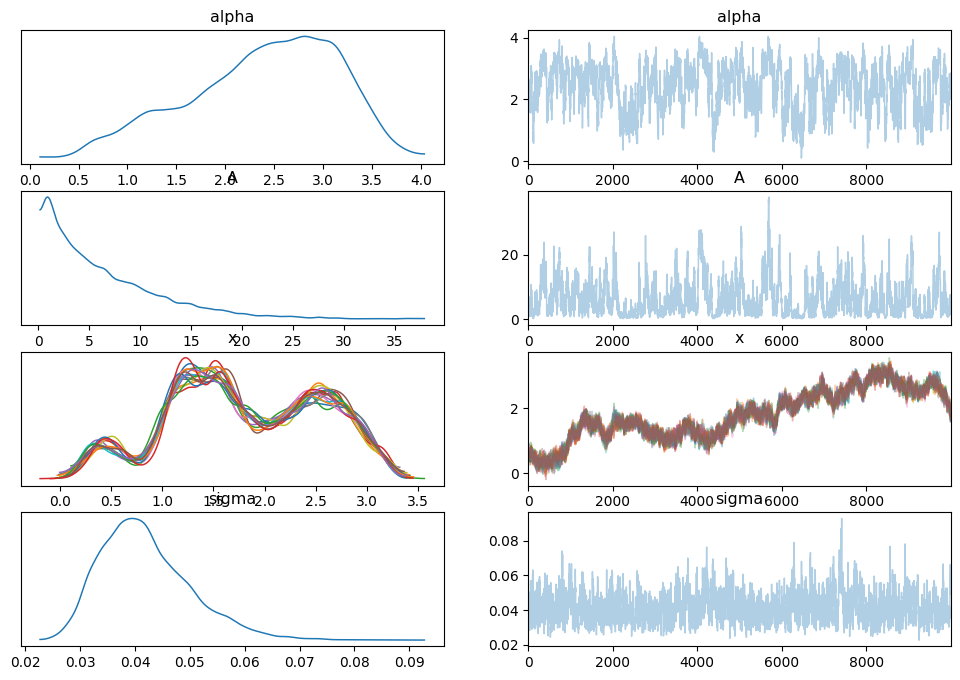

In [85]:
az.plot_trace(idata)
plt.show()

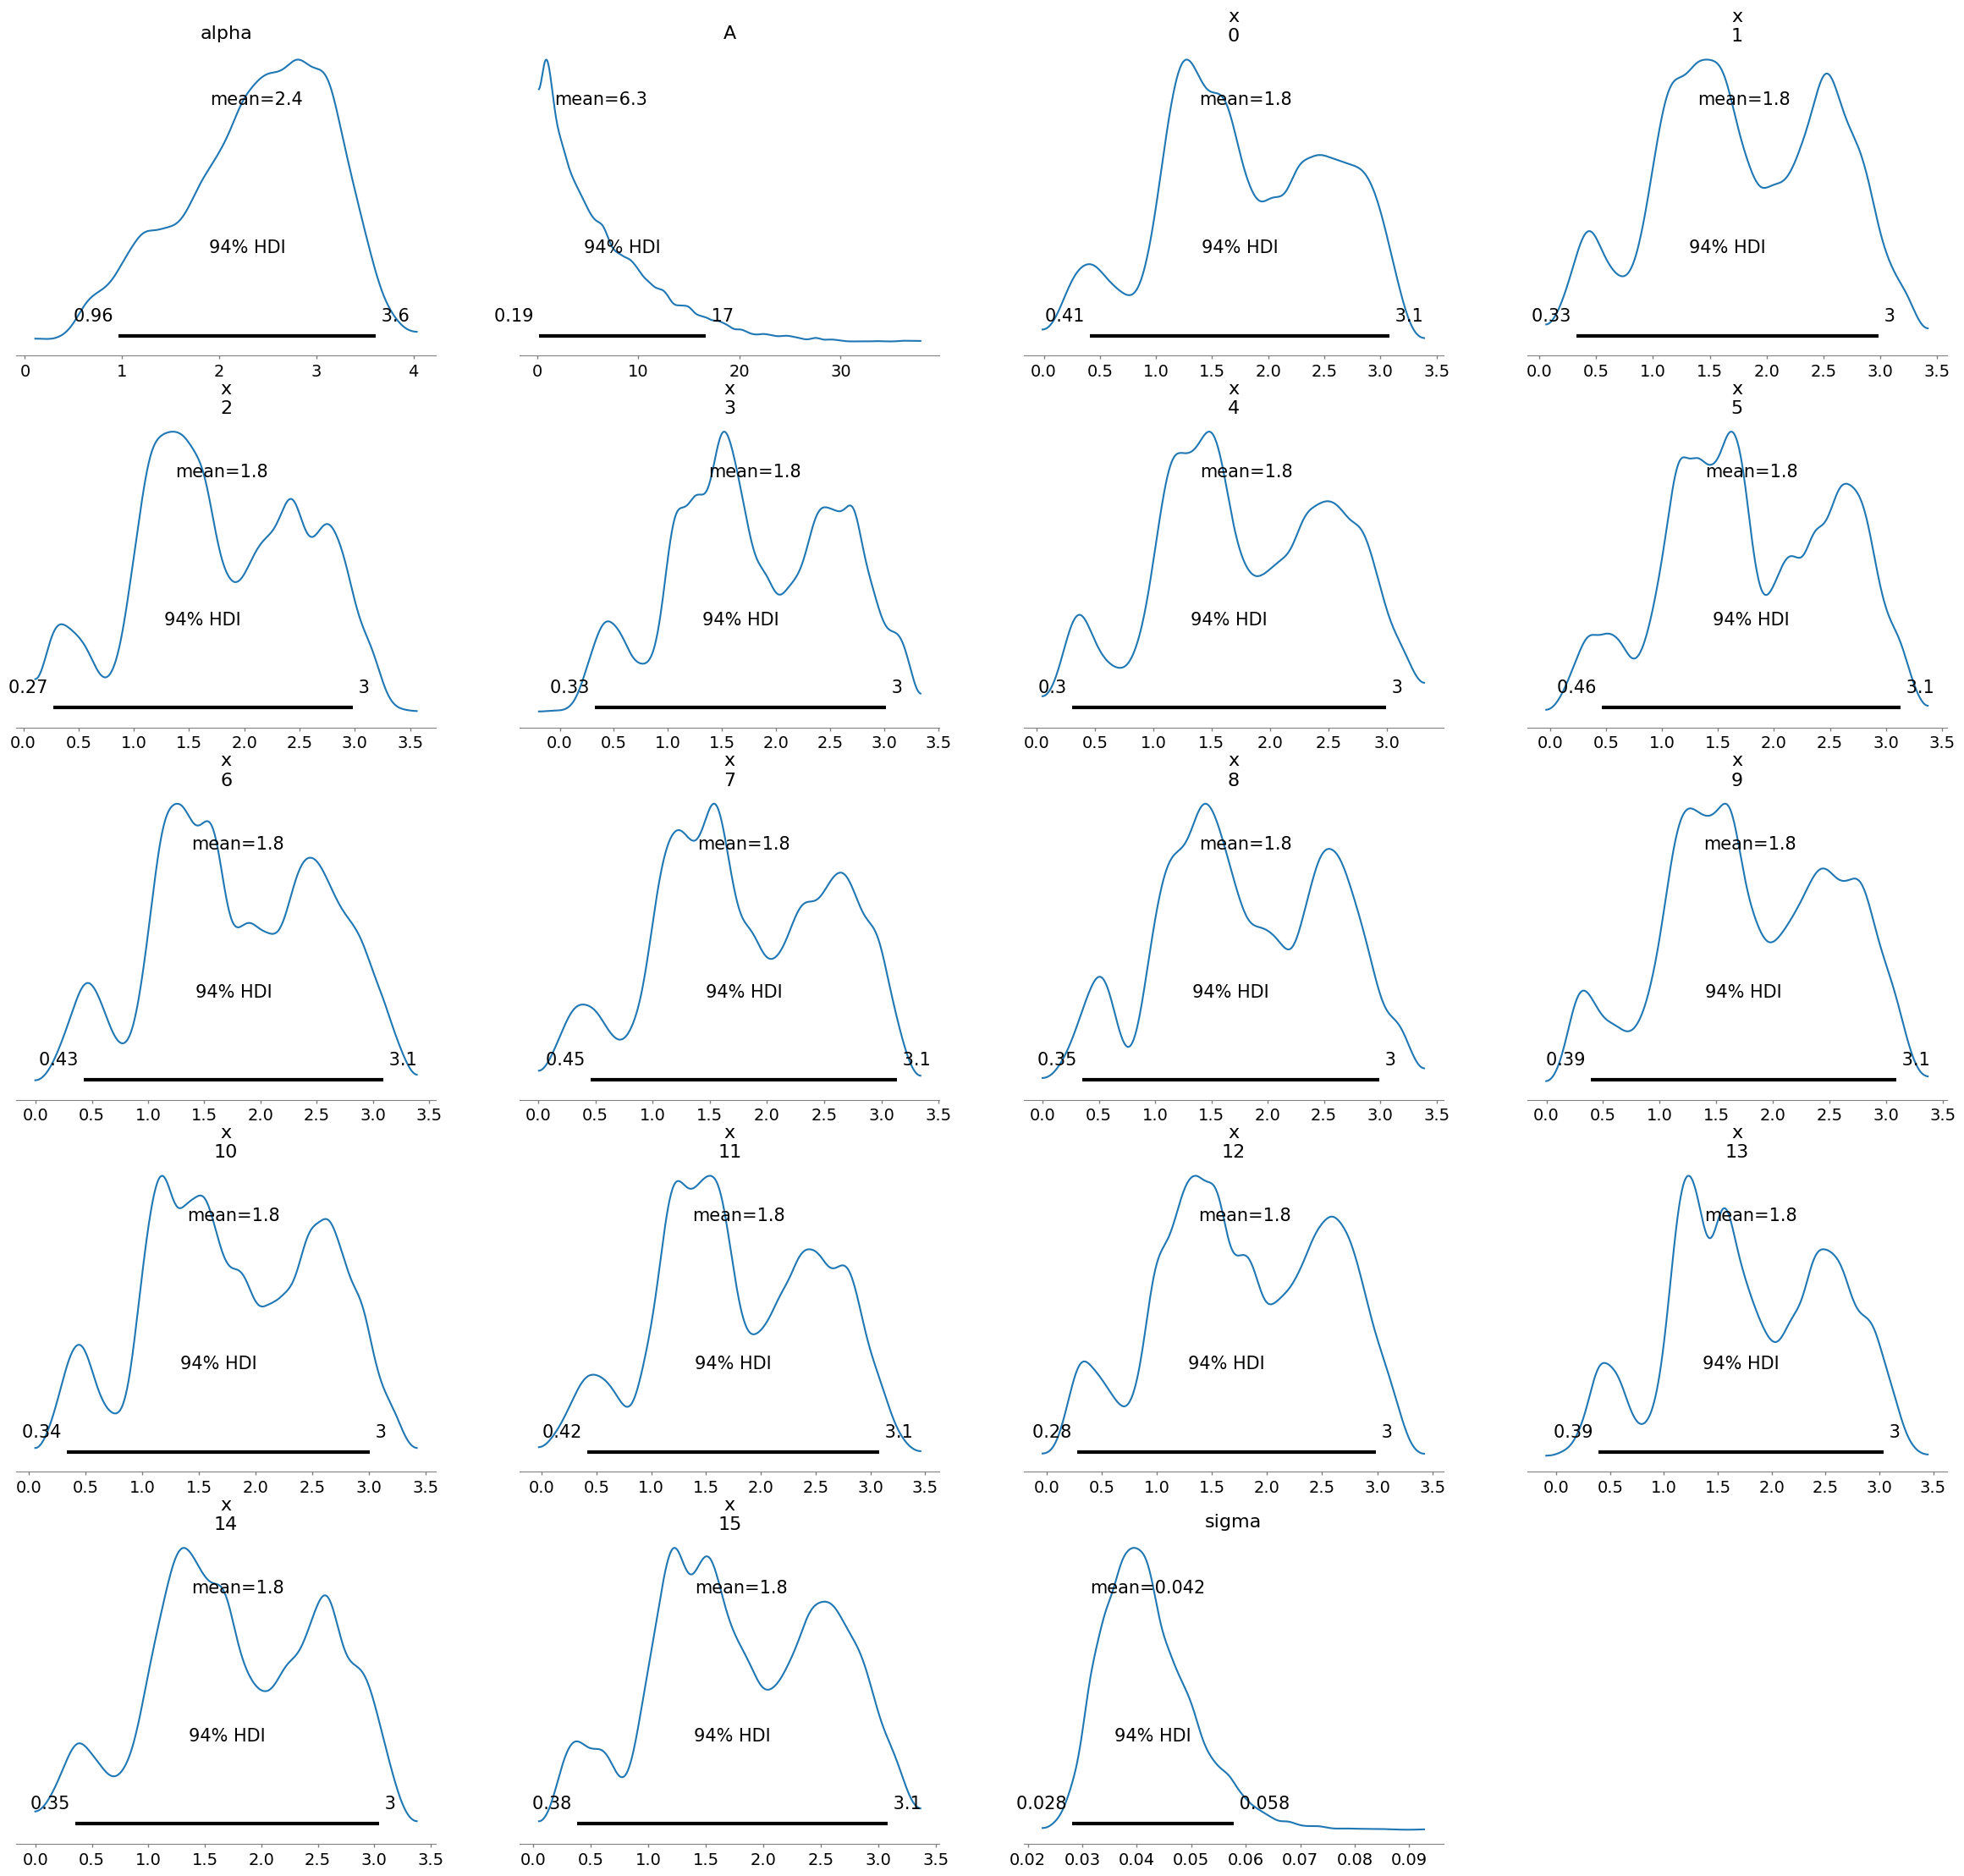

In [86]:
az.plot_posterior(idata)
plt.show()

/home/zoe/cosmographi/.venv/lib/python3.12/site-packages/arviz/plots/backends/matplotlib/pairplot.py:233: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


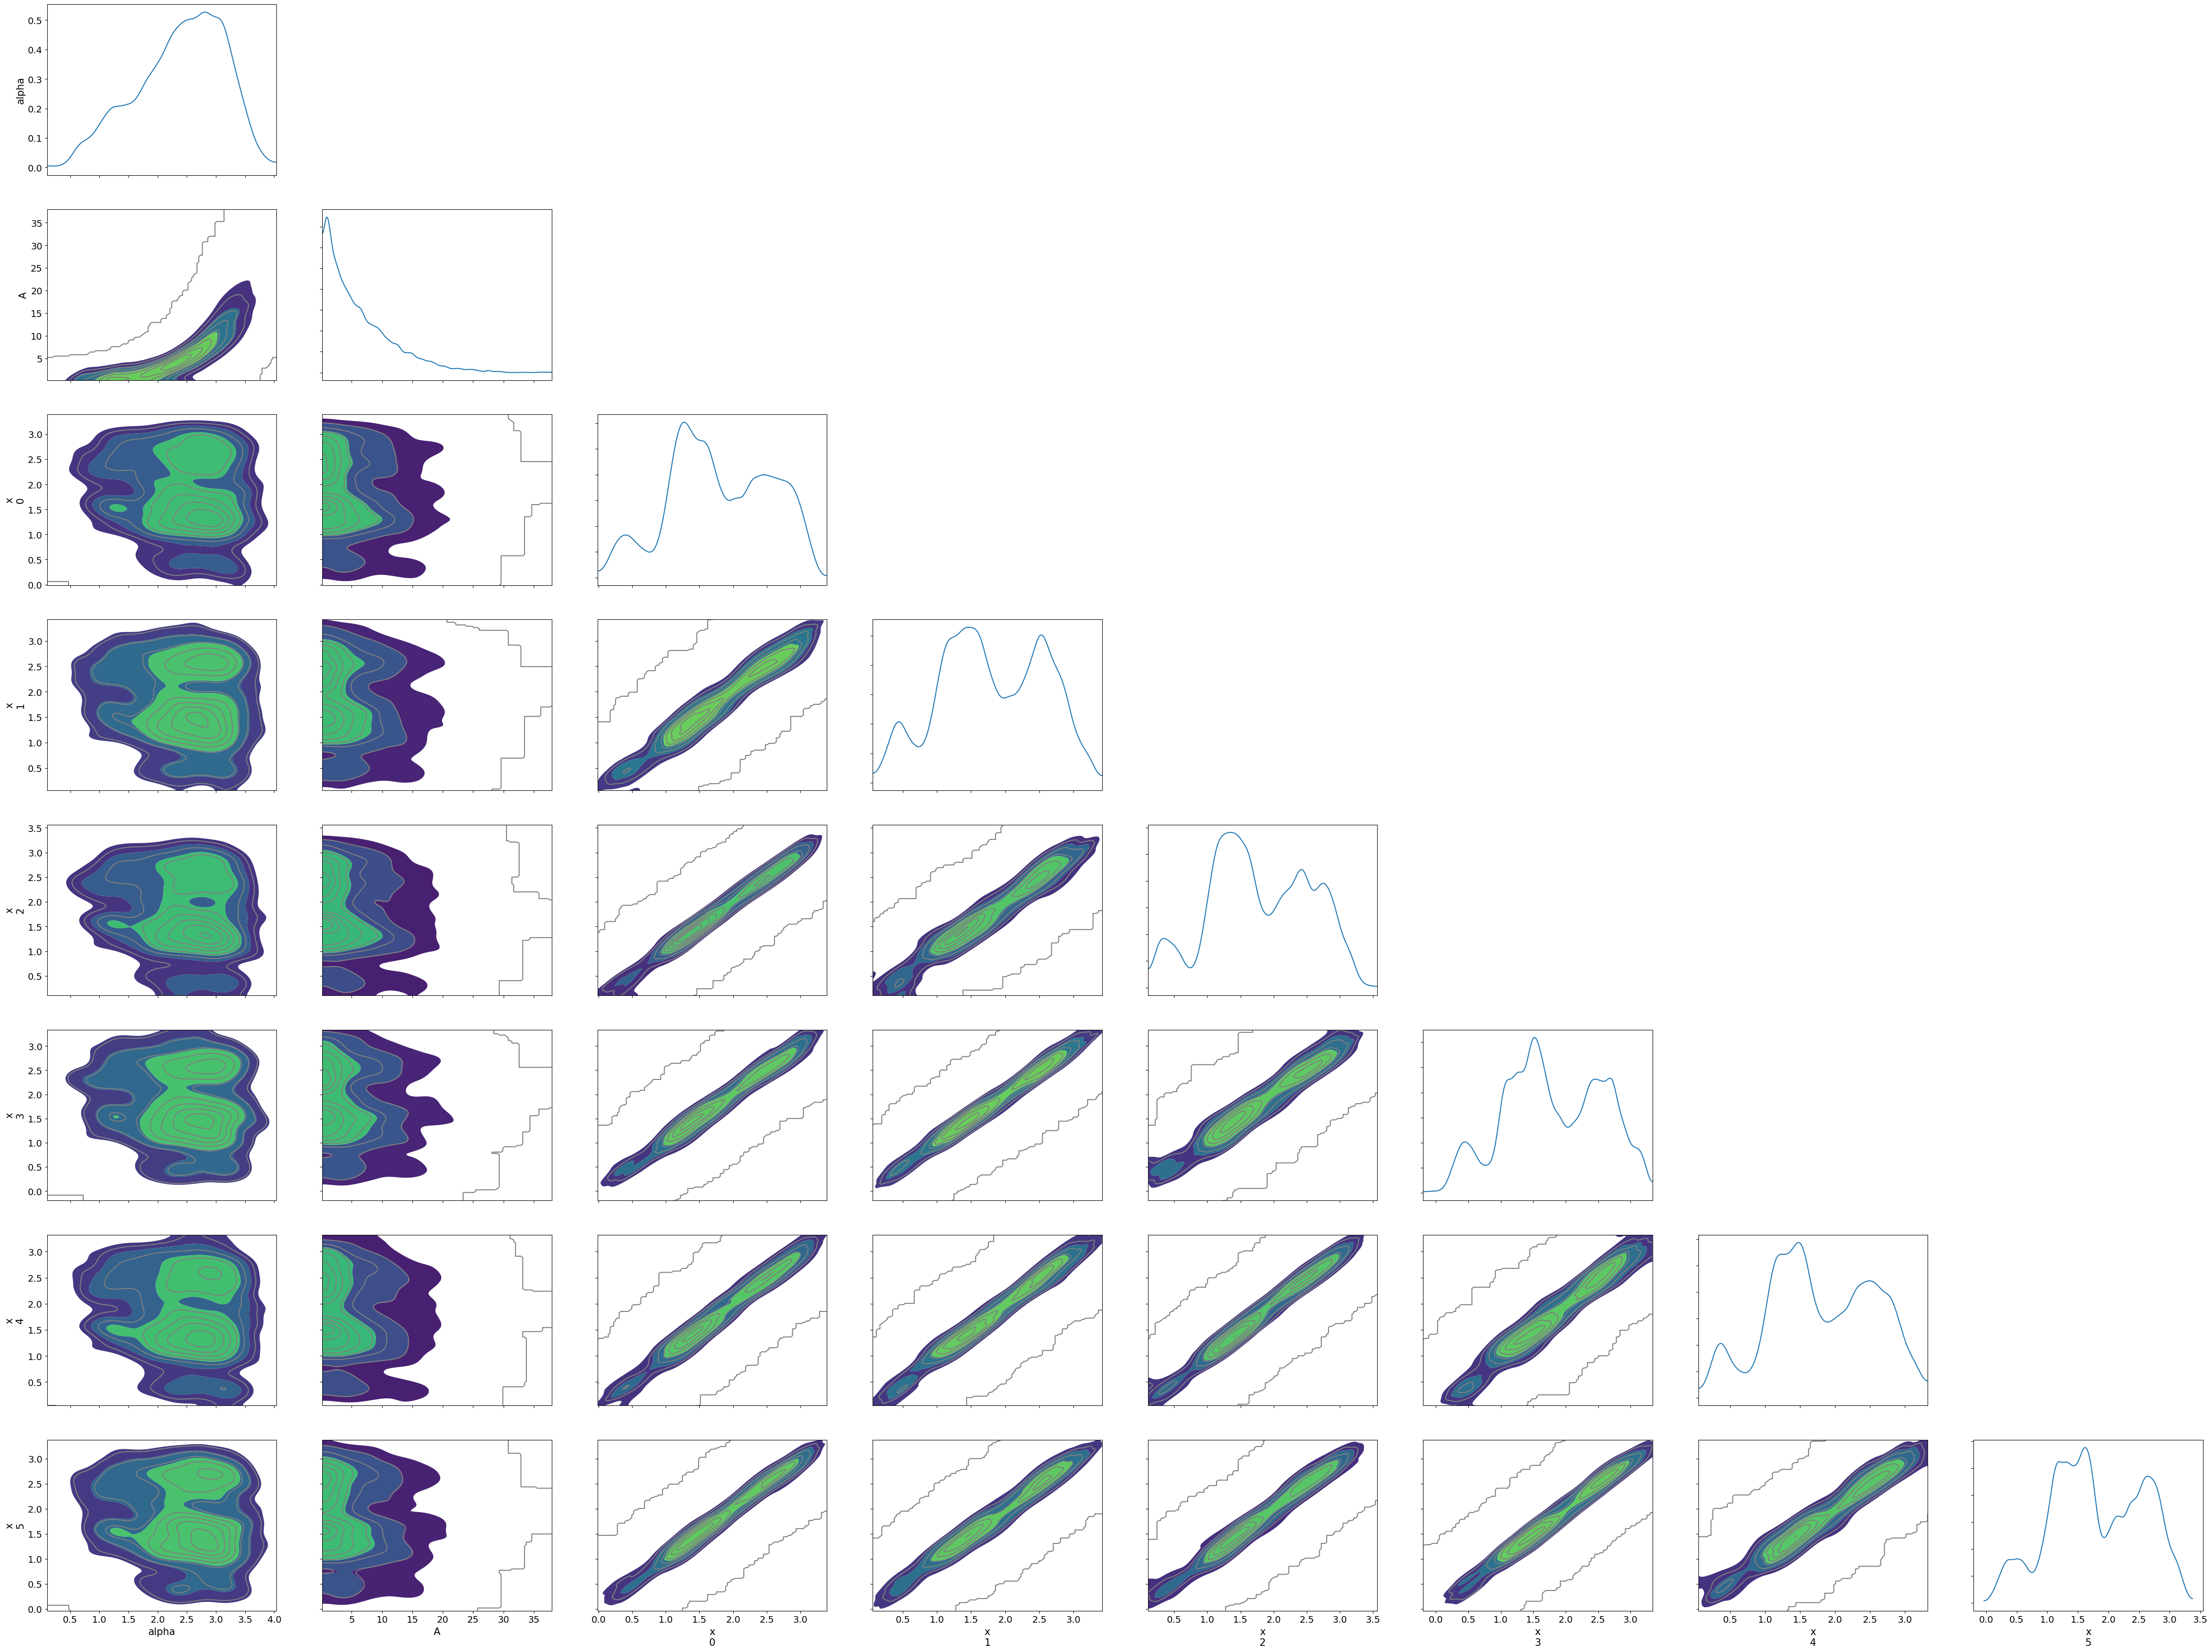

In [87]:
az.plot_pair(idata, kind="kde", marginals=True)
plt.show()

In [88]:
def fitted_spectrum_simple(alpha_samples, A_samples, sigma_samples, n_samples, band, averages, key):
   averages = averages.squeeze()
   print(averages.shape)
   print(sigma_samples.shape)
   perturbations = jax.vmap(generate_perturbation, in_axes=(0,0,None, None))(alpha_samples, A_samples, n_samples, key)
   mean = invert_bandwise_mean_norm(perturbations, band, averages).squeeze()
   sigma_samples = sigma_samples.squeeze()
   noise = sigma_samples[:, None] * jax.random.normal(key, shape=mean.shape)
   return noise + mean #should sepparaye keys

In [90]:
def invert_bandwise_mean_norm(y_norm, band, averages):
    return (y_norm + 1) * averages[band]

alpha_samples = idata.posterior["alpha"].values.flatten()
A_samples = idata.posterior["A"].values.flatten()
sigma_samples = idata.posterior["sigma"].values.flatten()
print(len(alpha_samples), len(A_samples), len(sigma_samples), len(x_samples))
ky = jax.random.key(1234)

pred_samples = fitted_spectrum_simple(alpha_samples, A_samples, sigma_samples, len(lc_obs), bands, y_mean, ky)

10000 10000 10000 10000
(6,)
(10000,)


In [91]:
posterior_spectra = np.asarray(pred_samples)
plotting_times = jnp.linspace(times[0], times[-1], posterior_spectra.shape[0])
print(posterior_spectra.shape)

(10000, 16)


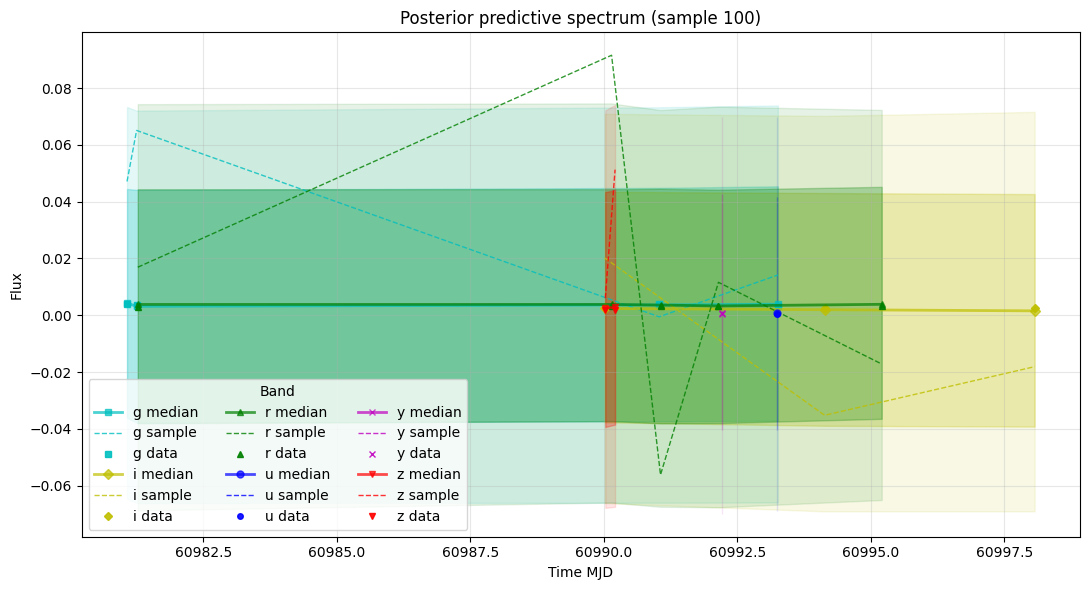

In [93]:
band_colors = {"u": "#0000FF", "g": "#00BFBF", "r": "#008000", "i": "#BFBF00", "z": "#FF0000", "y": "#BF00BF"}
band_markers = {"u": "o", "g": "s", "r": "^", "i": "D", "z": "v", "y": "x"}

sample_idx = 100
band_strs = np.array([idx_to_bandstr[b.item()] for b in bands])
unique_bands = np.unique(band_strs)
fig, ax1 = plt.subplots(figsize=(11, 6))

for b in unique_bands:
    mask = band_strs == b
    samples_band = posterior_spectra[:, mask]
    realization = samples_band[sample_idx]

    q16, q50, q84 = np.percentile(samples_band, [16, 50, 84], axis=0)
    q05, q95 = np.percentile(samples_band, [5, 95], axis=0)
    # in case theyre not ordered, akthough they should
    order = np.argsort(times[mask])
    t = times[mask][order]
    realization = realization[order]
    q16 = q16[order]
    q50 = q50[order]
    q84 = q84[order]
    q05 = q05[order]
    q95 = q95[order]
    color = band_colors[b]
    # 90% credible interval
    ax1.fill_between(
        t,
        q05,
        q95,
        color=color,
        alpha=0.10
    )
    # 68% credible interval
    ax1.fill_between(
        t,
        q16,
        q84,
        color=color,
        alpha=0.25
    )
    # Posterior median
    ax1.plot(
        t,
        q50,
        color=color,
        marker=band_markers[b],
        linestyle="-",
        linewidth=2,
        markersize=5,
        alpha=0.7,
        label=f"{b} median"
    )
    # One posterior predictive realization
    ax1.plot(
        t,
        realization,
        color=color,
        linestyle="--",
        linewidth=1,
        alpha=0.8,
        label=f"{b} sample"
    )
    # Original data
    ax1.plot(
        t,
        lc_obs[mask][order],
        color=color,
        marker=band_markers[b],
        linestyle="none",
        markersize=4,
        alpha=0.9,
        label=f"{b} data"
    )
ax1.set_xlabel("Time MJD")
ax1.set_ylabel("Flux")
ax1.set_title(
    f"Posterior predictive spectrum (sample {sample_idx})"
)
ax1.legend(title="Band", ncol=3)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()